<a href="https://colab.research.google.com/github/OJB-Quantum/QC-Hardware-How-To/blob/main/Jupyter%20Notebook%20Scripts/Elbow_Coupled_CPW_Resonator_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [34]:
!uv pip install --system -q phidl matplotlib gdstk

Generated parallel elbow-coupled CPW layout.
CPW trace width: 10.000 um
CPW gap width: 5.000 um
Full CPW drawn width: 20.000 um
Elbow parallel arm length: 125.000 um
Elbow perpendicular arm length: 80.000 um
Elbow bend radius: 30.000 um
Straight CPW length: 400.000 um
Parallel edge-to-edge spacing: 15.000 um
Device bounding box in micrometers: [[   0. -110.]
 [ 400.   45.]]


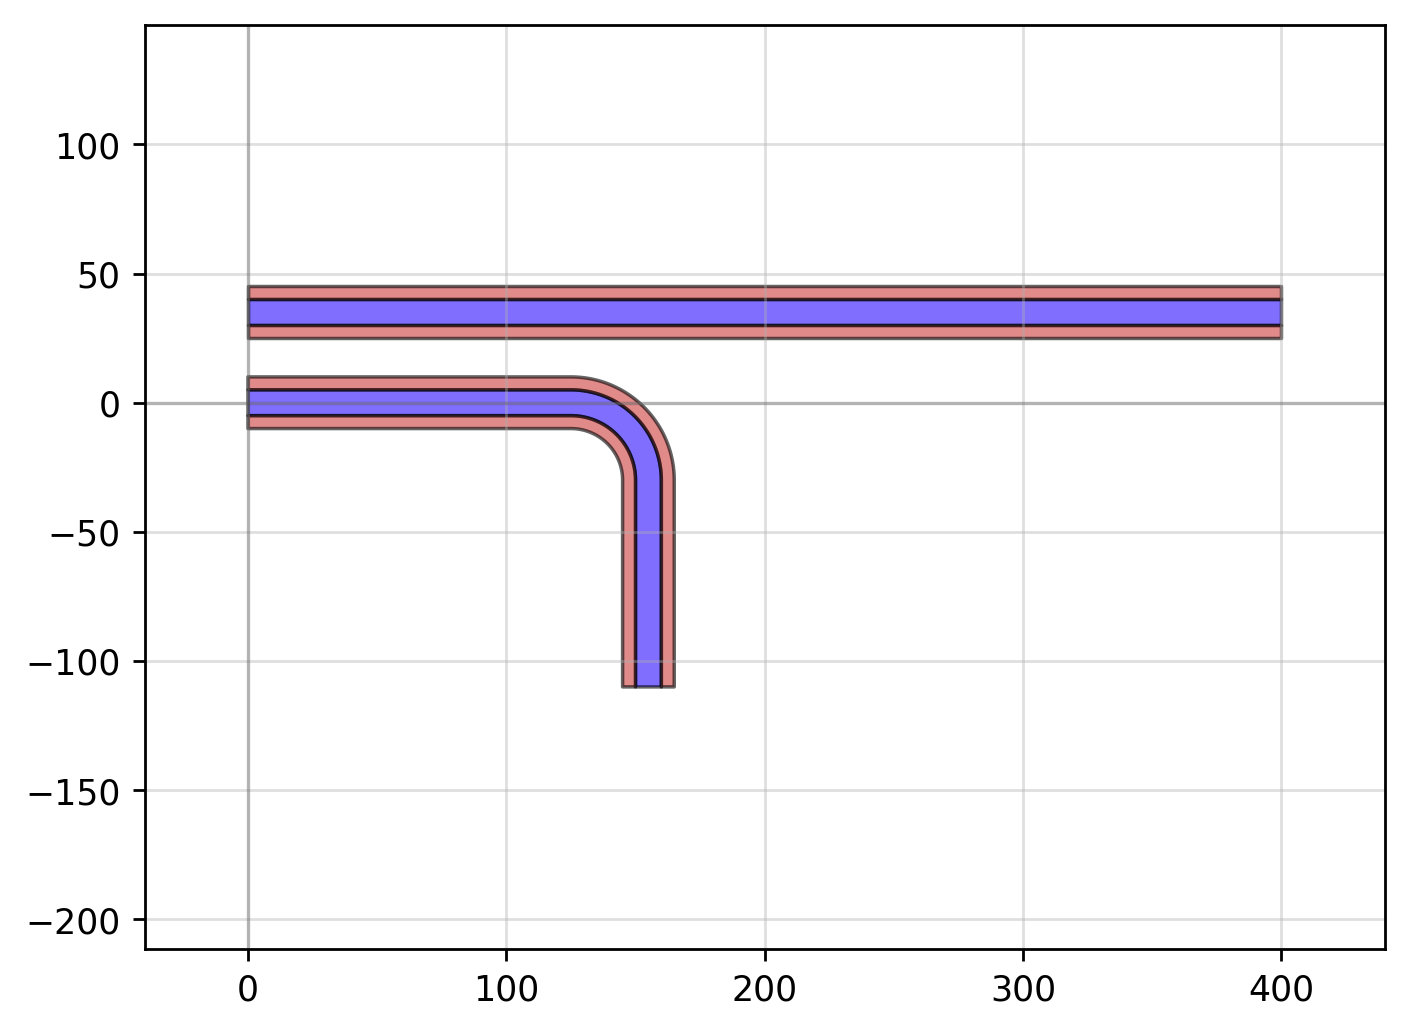

In [35]:
"""
Generate an elbow-coupled coplanar waveguide layout with a parallel coupler.

This script synthesizes a microwave coplanar waveguide geometry in PHIDL. The
elbow CPW contains one horizontal arm that is intentionally placed parallel to
an adjacent straight CPW. The second elbow arm bends downward so that the
parallel coupling region remains geometrically clean and tunable.

All geometry dimensions are expressed in micrometers, which is the standard
coordinate scale used for GDSII mask layout workflows.
"""

from dataclasses import dataclass
from pathlib import Path as FilePath
from typing import Literal

import gdstk
import matplotlib as mpl
import matplotlib.pyplot as plt
import phidl.path as pp
from phidl import CrossSection, Device, quickplot


# =============================================================================
# CONTROL KNOBS
# =============================================================================

# CPW transverse geometry, in micrometers.
CPW_TRACE_WIDTH_UM = 10.0
CPW_GAP_WIDTH_UM = 5.0

# Elbow CPW centerline geometry, in micrometers.
ELBOW_PARALLEL_ARM_LENGTH_UM = 125.0
ELBOW_PERPENDICULAR_ARM_LENGTH_UM = 80.0
ELBOW_BEND_RADIUS_UM = 30.0
ELBOW_BEND_DIRECTION: Literal["up", "down"] = "down"

# Straight CPW geometry and placement, in micrometers.
STRAIGHT_CPW_LENGTH_UM = 400.0
STRAIGHT_CPW_X_OFFSET_UM = 0.0
PARALLEL_EDGE_TO_EDGE_SPACING_UM = 15.0

# GDS layers.
LAYER_TRACE = 1
LAYER_GAP = 2

# Plot settings.
PLOT_DPI = 250
FONT_SANS_SERIF = ["Tahoma", "DejaVu Sans"]
FONT_WEIGHT = "normal"

# Device names.
TOP_LEVEL_DEVICE_NAME = "Parallel_Elbow_CPW_Assembly"
ELBOW_DEVICE_NAME = "Elbow_CPW_With_Parallel_Arm"
STRAIGHT_DEVICE_NAME = "Straight_CPW"

# Optional GDS export settings.
WRITE_GDS = False
VALIDATE_GDS_WITH_GDSTK = True
GDS_OUTPUT_PATH = FilePath("parallel_elbow_cpw_assembly.gds")


@dataclass(frozen=True)
class CpwGeometry:
    """Coplanar waveguide transverse geometry in micrometers."""

    trace_width_um: float
    gap_width_um: float
    trace_layer: int
    gap_layer: int

    @property
    def full_width_um(self) -> float:
        """Return the full CPW drawing width, including both slot gaps."""
        return self.trace_width_um + 2.0 * self.gap_width_um


@dataclass(frozen=True)
class ElbowGeometry:
    """Elbow CPW centerline geometry in micrometers."""

    parallel_arm_length_um: float
    perpendicular_arm_length_um: float
    bend_radius_um: float
    bend_direction: Literal["up", "down"]


@dataclass(frozen=True)
class StraightCpwGeometry:
    """Straight CPW centerline geometry and placement in micrometers."""

    length_um: float
    x_offset_um: float
    parallel_edge_to_edge_spacing_um: float


def configure_matplotlib() -> None:
    """Configure Matplotlib for high-resolution notebook rendering."""
    mpl.rcParams["figure.dpi"] = PLOT_DPI
    mpl.rcParams["font.sans-serif"] = FONT_SANS_SERIF
    mpl.rcParams["font.weight"] = FONT_WEIGHT


def validate_positive_value(name: str, value: float) -> None:
    """Raise a ValueError when a dimensional control value is nonpositive."""
    if value <= 0.0:
        raise ValueError(f"{name} must be positive. Received {value}.")


def validate_nonnegative_value(name: str, value: float) -> None:
    """Raise a ValueError when a spacing or offset value is negative."""
    if value < 0.0:
        raise ValueError(f"{name} must be nonnegative. Received {value}.")


def validate_geometry(
    cpw: CpwGeometry,
    elbow: ElbowGeometry,
    straight: StraightCpwGeometry,
) -> None:
    """Validate all geometry control knobs before layout generation."""
    validate_positive_value("trace_width_um", cpw.trace_width_um)
    validate_positive_value("gap_width_um", cpw.gap_width_um)
    validate_positive_value(
        "parallel_arm_length_um",
        elbow.parallel_arm_length_um,
    )
    validate_positive_value(
        "perpendicular_arm_length_um",
        elbow.perpendicular_arm_length_um,
    )
    validate_positive_value("bend_radius_um", elbow.bend_radius_um)
    validate_positive_value("straight_cpw_length_um", straight.length_um)
    validate_nonnegative_value(
        "parallel_edge_to_edge_spacing_um",
        straight.parallel_edge_to_edge_spacing_um,
    )


def build_cpw_cross_section(cpw: CpwGeometry) -> CrossSection:
    """
    Build a three-strip CPW drawing cross section.

    The center strip represents the signal trace. The two offset strips
    represent slot-gap regions on each side of the trace, placed on a separate
    layer for downstream Boolean processing or electromagnetic preprocessing.
    """
    half_trace_width_um = cpw.trace_width_um / 2.0
    half_gap_width_um = cpw.gap_width_um / 2.0
    gap_offset_um = half_trace_width_um + half_gap_width_um

    cross_section = CrossSection()
    cross_section.add(
        width=cpw.trace_width_um,
        offset=0.0,
        layer=cpw.trace_layer,
    )
    cross_section.add(
        width=cpw.gap_width_um,
        offset=gap_offset_um,
        layer=cpw.gap_layer,
    )
    cross_section.add(
        width=cpw.gap_width_um,
        offset=-gap_offset_um,
        layer=cpw.gap_layer,
    )

    return cross_section


def get_bend_angle_degrees(direction: Literal["up", "down"]) -> float:
    """Return the signed bend angle for the requested elbow direction."""
    if direction == "up":
        return 90.0

    return -90.0


def build_elbow_cpw(
    cross_section: CrossSection,
    elbow: ElbowGeometry,
) -> Device:
    """
    Create an elbow CPW with one horizontal arm used as the coupling section.

    The path begins along positive x, creating the parallel-coupling arm. It
    then bends by 90 degrees and continues along the perpendicular feed arm.
    """
    elbow_path = pp.Path()
    elbow_path.append(pp.straight(length=elbow.parallel_arm_length_um))
    elbow_path.append(
        pp.arc(
            radius=elbow.bend_radius_um,
            angle=get_bend_angle_degrees(elbow.bend_direction),
        )
    )
    elbow_path.append(pp.straight(length=elbow.perpendicular_arm_length_um))

    elbow_device = elbow_path.extrude(cross_section)
    elbow_device.name = ELBOW_DEVICE_NAME

    return elbow_device


def build_straight_cpw(
    cross_section: CrossSection,
    straight: StraightCpwGeometry,
) -> Device:
    """Create a straight CPW resonator path."""
    straight_path = pp.Path()
    straight_path.append(pp.straight(length=straight.length_um))

    straight_device = straight_path.extrude(cross_section)
    straight_device.name = STRAIGHT_DEVICE_NAME

    return straight_device


def assemble_parallel_elbow_circuit(
    cpw: CpwGeometry,
    elbow: ElbowGeometry,
    straight: StraightCpwGeometry,
) -> Device:
    """
    Assemble the elbow CPW and straight CPW with a parallel coupling region.
    """
    validate_geometry(cpw=cpw, elbow=elbow, straight=straight)

    cross_section = build_cpw_cross_section(cpw=cpw)
    elbow_device = build_elbow_cpw(
        cross_section=cross_section,
        elbow=elbow,
    )
    straight_device = build_straight_cpw(
        cross_section=cross_section,
        straight=straight,
    )

    top_level_device = Device(name=TOP_LEVEL_DEVICE_NAME)
    elbow_reference = top_level_device << elbow_device
    straight_reference = top_level_device << straight_device

    elbow_parallel_arm_top_y_um = cpw.full_width_um / 2.0
    straight_reference.ymin = (
        elbow_parallel_arm_top_y_um
        + straight.parallel_edge_to_edge_spacing_um
    )
    straight_reference.xmin = straight.x_offset_um

    return top_level_device


def write_gds_file(device: Device, output_path: FilePath) -> None:
    """Write the PHIDL device to a GDSII file."""
    device.write_gds(str(output_path))
    print(f"Wrote GDS file: {output_path}")


def validate_gds_file_with_gdstk(gds_path: FilePath) -> None:
    """Read an exported GDSII file with GDSTK and print a compact summary."""
    library = gdstk.read_gds(str(gds_path))
    top_cells = library.top_level()

    if len(top_cells) == 0:
        raise RuntimeError("GDSTK readback found zero top-level cells.")

    print("GDSTK validation passed.")
    print(f"Top-level cell count: {len(top_cells)}")

    for cell in top_cells:
        print(
            f"Cell '{cell.name}': "
            f"{len(cell.polygons)} polygons, "
            f"{len(cell.references)} references"
        )


def plot_device(device: Device) -> None:
    """Render the PHIDL device directly in the notebook output."""
    quickplot(device)
    plt.show()


def main() -> Device:
    """Generate, render, and optionally validate the CPW layout."""
    configure_matplotlib()

    cpw = CpwGeometry(
        trace_width_um=CPW_TRACE_WIDTH_UM,
        gap_width_um=CPW_GAP_WIDTH_UM,
        trace_layer=LAYER_TRACE,
        gap_layer=LAYER_GAP,
    )
    elbow = ElbowGeometry(
        parallel_arm_length_um=ELBOW_PARALLEL_ARM_LENGTH_UM,
        perpendicular_arm_length_um=ELBOW_PERPENDICULAR_ARM_LENGTH_UM,
        bend_radius_um=ELBOW_BEND_RADIUS_UM,
        bend_direction=ELBOW_BEND_DIRECTION,
    )
    straight = StraightCpwGeometry(
        length_um=STRAIGHT_CPW_LENGTH_UM,
        x_offset_um=STRAIGHT_CPW_X_OFFSET_UM,
        parallel_edge_to_edge_spacing_um=PARALLEL_EDGE_TO_EDGE_SPACING_UM,
    )

    device = assemble_parallel_elbow_circuit(
        cpw=cpw,
        elbow=elbow,
        straight=straight,
    )

    print("Generated parallel elbow-coupled CPW layout.")
    print(f"CPW trace width: {cpw.trace_width_um:.3f} um")
    print(f"CPW gap width: {cpw.gap_width_um:.3f} um")
    print(f"Full CPW drawn width: {cpw.full_width_um:.3f} um")
    print(f"Elbow parallel arm length: {elbow.parallel_arm_length_um:.3f} um")
    print(
        "Elbow perpendicular arm length: "
        f"{elbow.perpendicular_arm_length_um:.3f} um"
    )
    print(f"Elbow bend radius: {elbow.bend_radius_um:.3f} um")
    print(f"Straight CPW length: {straight.length_um:.3f} um")
    print(
        "Parallel edge-to-edge spacing: "
        f"{straight.parallel_edge_to_edge_spacing_um:.3f} um"
    )
    print(f"Device bounding box in micrometers: {device.bbox}")

    if WRITE_GDS:
        write_gds_file(device=device, output_path=GDS_OUTPUT_PATH)

        if VALIDATE_GDS_WITH_GDSTK:
            validate_gds_file_with_gdstk(gds_path=GDS_OUTPUT_PATH)

    plot_device(device)

    return device


if __name__ == "__main__":
    microwave_device = main()

In [36]:
"""
Export the generated PHIDL microwave layout as an OASIS file using GDSTK.

This cell converts the already generated PHIDL device into a temporary GDSII
file, imports that GDSII file into GDSTK, writes an OASIS file, and validates
the OASIS file by reading it back with GDSTK.

The geometry coordinate convention remains micrometers because the PHIDL layout
was generated using micrometer-scale dimensions.
"""

from pathlib import Path

import gdstk


# =============================================================================
# CONTROL KNOBS
# =============================================================================

OASIS_OUTPUT_PATH = Path("parallel_elbow_cpw_assembly.oas")
TEMPORARY_GDS_PATH = Path("parallel_elbow_cpw_assembly_temp.gds")

REMOVE_TEMPORARY_GDS = False
VALIDATE_OASIS_READBACK = True


def export_phidl_device_to_oasis(
    device,
    temporary_gds_path: Path,
    oasis_output_path: Path,
) -> None:
    """
    Export a PHIDL device to OASIS by converting through GDSTK.

    Args:
        device: PHIDL Device object to export.
        temporary_gds_path: Temporary GDSII path used for PHIDL-to-GDSTK transfer.
        oasis_output_path: Final OASIS output path.
    """
    device.write_gds(str(temporary_gds_path))

    gdstk_library = gdstk.read_gds(str(temporary_gds_path))
    gdstk_library.write_oas(str(oasis_output_path))

    print(f"Wrote temporary GDSII file: {temporary_gds_path}")
    print(f"Wrote OASIS file: {oasis_output_path}")


def validate_oasis_file(oasis_output_path: Path) -> None:
    """
    Validate an OASIS file by reading it back with GDSTK.

    Args:
        oasis_output_path: OASIS file path to validate.
    """
    gdstk_library = gdstk.read_oas(str(oasis_output_path))
    top_cells = gdstk_library.top_level()

    if len(top_cells) == 0:
        raise RuntimeError("OASIS readback found zero top-level cells.")

    print("OASIS readback validation passed.")
    print(f"Top-level cell count: {len(top_cells)}")

    for cell in top_cells:
        print(
            f"Cell '{cell.name}': "
            f"{len(cell.polygons)} polygons, "
            f"{len(cell.references)} references"
        )


def main() -> None:
    """Export the generated microwave layout to OASIS."""
    if "microwave_device" not in globals():
        raise NameError(
            "microwave_device was not found. Run the layout-generation "
            "cell first, then run this OASIS export cell."
        )

    export_phidl_device_to_oasis(
        device=microwave_device,
        temporary_gds_path=TEMPORARY_GDS_PATH,
        oasis_output_path=OASIS_OUTPUT_PATH,
    )

    if VALIDATE_OASIS_READBACK:
        validate_oasis_file(oasis_output_path=OASIS_OUTPUT_PATH)

    if REMOVE_TEMPORARY_GDS and TEMPORARY_GDS_PATH.exists():
        TEMPORARY_GDS_PATH.unlink()
        print(f"Removed temporary GDSII file: {TEMPORARY_GDS_PATH}")


if __name__ == "__main__":
    main()

Wrote temporary GDSII file: parallel_elbow_cpw_assembly_temp.gds
Wrote OASIS file: parallel_elbow_cpw_assembly.oas
OASIS readback validation passed.
Top-level cell count: 1
Cell 'toplevel': 0 polygons, 2 references


In [37]:
%%bash
set -euo pipefail

python -m pip install -q uv

apt-get update -qq >/tmp/apt_update_stdout.log 2>/tmp/apt_update_stderr.log || {
    cat /tmp/apt_update_stdout.log
    cat /tmp/apt_update_stderr.log
    exit 1
}

apt-get install -y -qq libglu1-mesa >/tmp/apt_install.log 2>&1 || {
    cat /tmp/apt_install.log
    exit 1
}

grep -Ev \
    "Skipping acquire|r2u\.stat\.illinois\.edu|/sbin/ldconfig\.real: /usr/local/lib/.* is not a symbolic link" \
    /tmp/apt_install.log || true

if command -v nvidia-smi >/dev/null 2>&1; then
    echo "NVIDIA GPU detected. Installing CuPy CUDA 12 wheel."
    CUPY_PACKAGE="cupy-cuda12x"
else
    echo "No NVIDIA GPU detected. Skipping CuPy CUDA wheel."
    CUPY_PACKAGE=""
fi

uv pip install --system -q phidl gdstk gmsh numpy matplotlib ${CUPY_PACKAGE}

NVIDIA GPU detected. Installing CuPy CUDA 12 wheel.


In [38]:
"""Verify geometry, meshing, plotting, and optional GPU dependencies."""

import importlib

REQUIRED_MODULES = [
    "numpy",
    "matplotlib",
    "phidl",
    "gdstk",
    "gmsh",
]

for module_name in REQUIRED_MODULES:
    module = importlib.import_module(module_name)
    version = getattr(module, "__version__", "unknown")
    print(f"{module_name}: import passed, version {version}")

try:
    import cupy

    device_count = cupy.cuda.runtime.getDeviceCount()
    print(f"cupy: import passed, CUDA device count {device_count}")

    if device_count > 0:
        device_id = cupy.cuda.Device().id
        properties = cupy.cuda.runtime.getDeviceProperties(device_id)
        device_name = properties["name"].decode("utf-8")
        print(f"CUDA device {device_id}: {device_name}")

except Exception as exc:
    print(f"cupy: unavailable, NumPy fallback will be used. Reason: {exc}")

print("Dependency verification completed.")

numpy: import passed, version 2.0.2
matplotlib: import passed, version 3.10.0
phidl: import passed, version 1.7.2
gdstk: import passed, version 1.0.0
gmsh: import passed, version 4.15.2
cupy: import passed, CUDA device count 1
CUDA device 0: Tesla T4
Dependency verification completed.


Preview filtering backend: CuPy/T4
Source polygons: 6
Ground box width: 420.000 um
Ground box height: 420.000 um


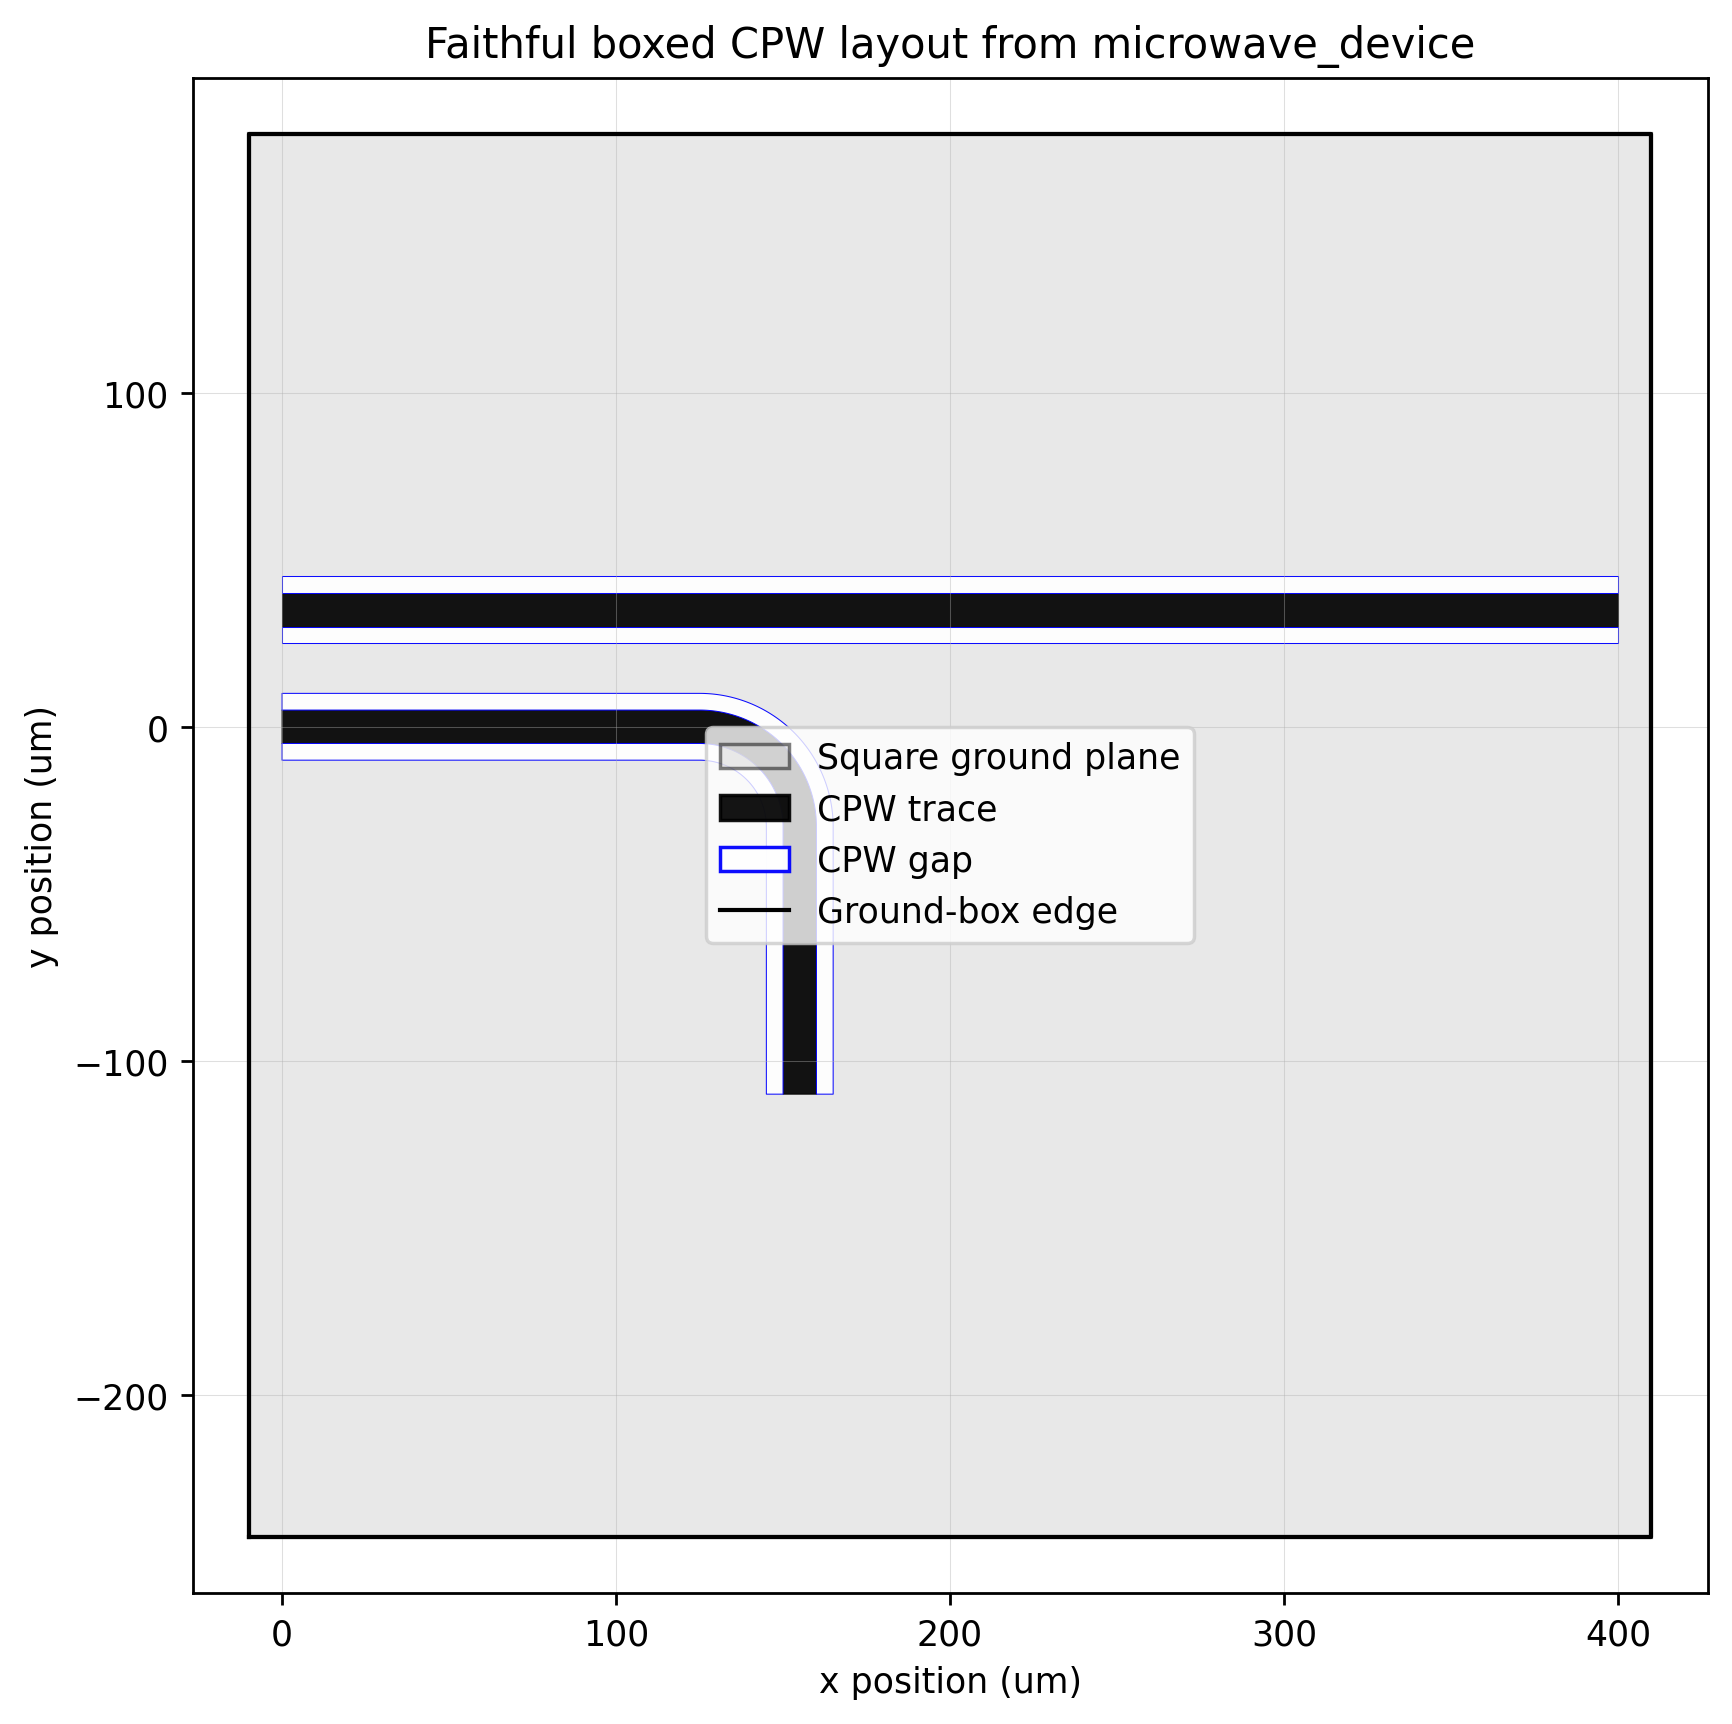

Generated actual Gmsh adaptive mesh.
Mesh generation and extraction time: 0.58 s
Mesh nodes: 13,239
Mesh triangles: 26,243
Trace metal surfaces meshed: 2
Wrote mesh file: faithful_cpw_boxed_gmsh_adaptive_with_trace.msh


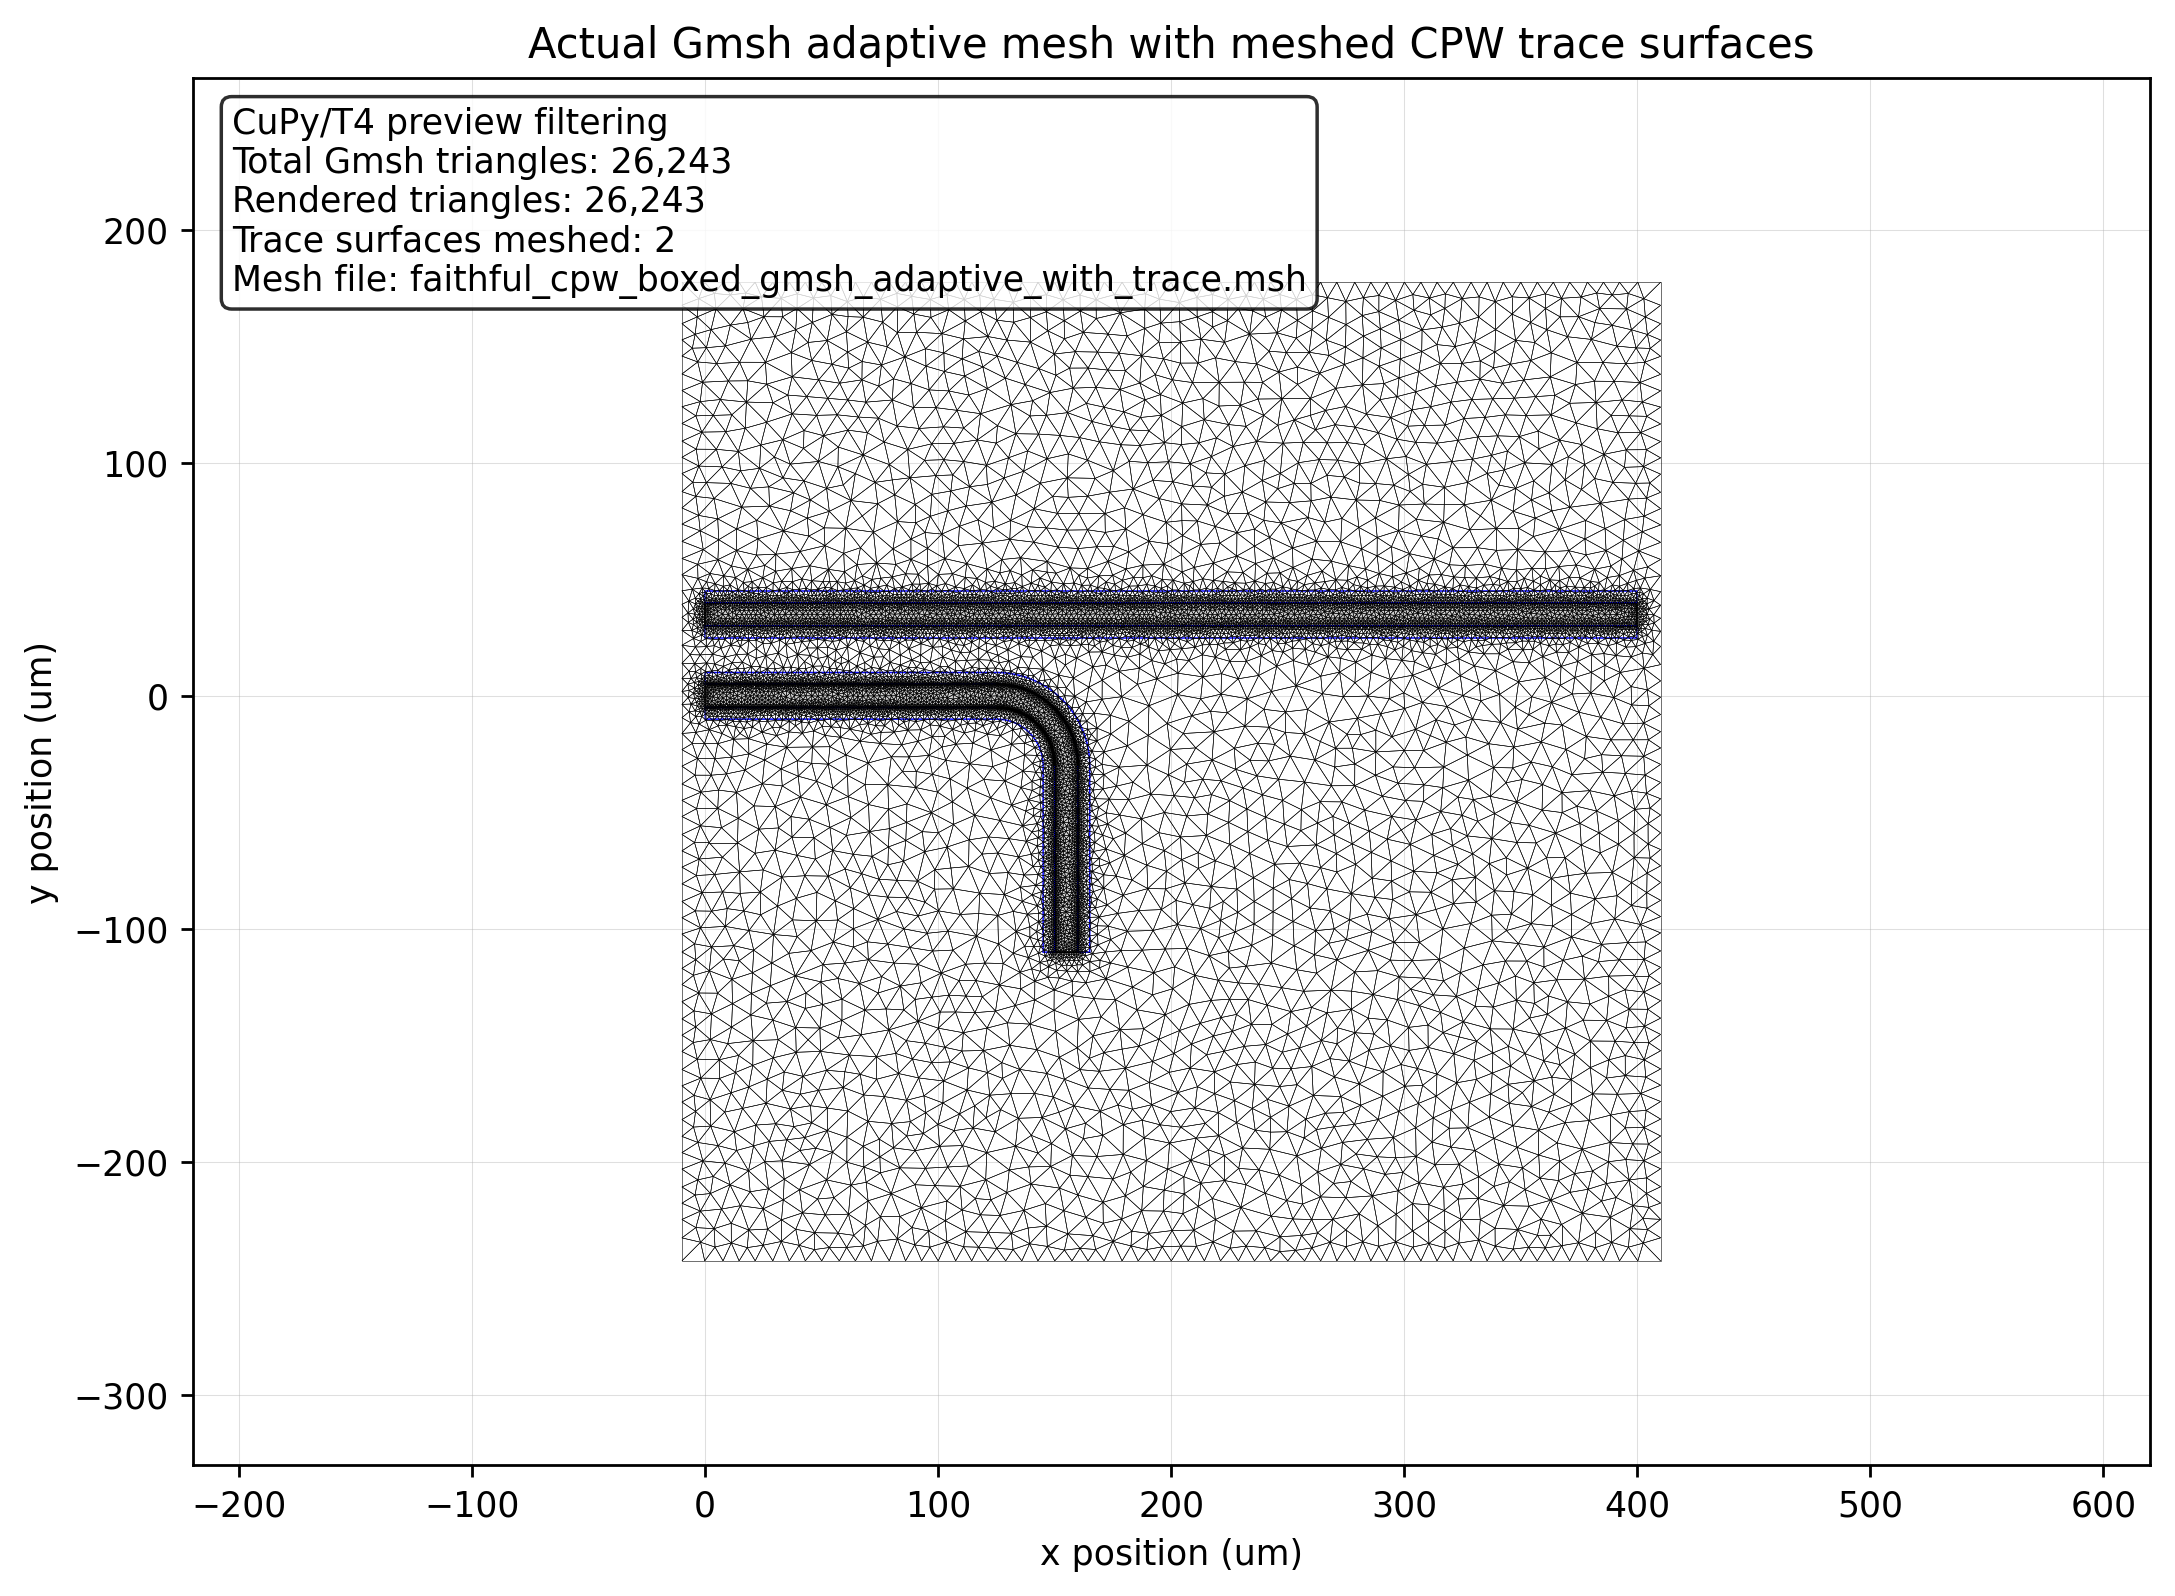

In [39]:
"""
Fast Gmsh adaptive mesh generation for an existing PHIDL CPW layout.

This cell uses the existing ``microwave_device`` as the geometry source, adds a
square surrounding ground box, generates a real Gmsh .msh file, meshes both the
surrounding dielectric region and the CPW trace metal surfaces, and renders a
CuPy-filtered preview of the resulting Gmsh mesh.

Gmsh performs actual unstructured mesh generation on the CPU. CuPy is used only
for fast preview filtering and decimation on a CUDA GPU.
"""

from dataclasses import dataclass
from pathlib import Path
from typing import Any

import gmsh
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection, PatchCollection
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.patches import Polygon as MatplotlibPolygon


# =============================================================================
# CONTROL KNOBS
# =============================================================================

# Layout layers from the CPW generator.
LAYER_TRACE = 1
LAYER_GAP = 2
LAYER_GROUND_PLANE = 10

# Ground box geometry, in micrometers.
GROUND_BOX_CLEARANCE_UM = 10.0
GROUND_BOX_FORCE_SQUARE = True

# Gmsh output.
WRITE_MSH_FILE = True
MESH_OUTPUT_PATH = Path("faithful_cpw_boxed_gmsh_adaptive_with_trace.msh")

# Gmsh adaptive mesh sizing, in micrometers.
FEATURE_MESH_SIZE_MIN_UM = 1.20 # Make bigger(up to 2.5) for even faster mesh generation
FEATURE_MESH_SIZE_MAX_UM = 10.00
FEATURE_REFINE_DISTANCE_MIN_UM = 2.00
FEATURE_REFINE_DISTANCE_MAX_UM = 18.00

OUTER_BOX_MESH_SIZE_MIN_UM = 7.00
OUTER_BOX_MESH_SIZE_MAX_UM = 30.00
OUTER_BOX_REFINE_DISTANCE_MIN_UM = 8.00
OUTER_BOX_REFINE_DISTANCE_MAX_UM = 42.00

DISTANCE_FIELD_SAMPLING_POINTS = 18

# Geometry fidelity and speed.
MESH_TRACE_METAL_SURFACES = True
TRACE_MESH_SIZE_UM = FEATURE_MESH_SIZE_MIN_UM

EMBED_GAP_OUTER_EDGES = False # Make False for even faster mesh generation
REMOVE_GAP_EDGES_COINCIDENT_WITH_TRACE = True
DUPLICATE_EDGE_TOLERANCE_UM = 1.0e-5

# Gmsh controls.
MESH_ALGORITHM_2D = 5
GENERAL_NUM_THREADS = 0
SUPPRESS_GMSH_OUTPUT = True
OPTIMIZE_MESH = False

# Physical group tags.
DIELECTRIC_SURFACE_PHYSICAL_TAG = 100
TRACE_SURFACE_PHYSICAL_TAG = 101
OUTER_BOUNDARY_PHYSICAL_TAG = 200
TRACE_BOUNDARY_PHYSICAL_TAG = 201
GAP_FEATURE_PHYSICAL_TAG = 202

# Preview controls.
PLOT_DPI = 250
LAYOUT_FIGURE_SIZE = (8.4, 7.0)
MESH_FIGURE_SIZE = (8.8, 7.2)
MESH_LINE_WIDTH = 0.16
MAX_RENDERED_TRIANGLES = 45_000
MESH_PREVIEW_MARGIN_FACTOR = 0.55

TRACE_PREVIEW_FILL_ALPHA = 0.18
TRACE_PREVIEW_EDGE_WIDTH = 0.60
GAP_PREVIEW_EDGE_WIDTH = 0.45

# Diagnostics.
PRINT_TIMING = True


@dataclass(frozen=True)
class LayoutPolygon:
    """Store one exact PHIDL polygon."""

    points_um: np.ndarray
    layer: int
    datatype: int = 0


@dataclass(frozen=True)
class GroundBox:
    """Store square ground-box bounds in micrometers."""

    xmin_um: float
    ymin_um: float
    xmax_um: float
    ymax_um: float

    @property
    def width_um(self) -> float:
        """Return the box width."""
        return self.xmax_um - self.xmin_um

    @property
    def height_um(self) -> float:
        """Return the box height."""
        return self.ymax_um - self.ymin_um

    @property
    def points_um(self) -> np.ndarray:
        """Return counterclockwise box points."""
        return np.array(
            [
                [self.xmin_um, self.ymin_um],
                [self.xmax_um, self.ymin_um],
                [self.xmax_um, self.ymax_um],
                [self.xmin_um, self.ymax_um],
            ],
            dtype=float,
        )


@dataclass(frozen=True)
class GmshMesh:
    """Store extracted Gmsh mesh arrays."""

    xy_coordinates_um: np.ndarray
    triangles: np.ndarray


def configure_matplotlib() -> None:
    """Configure Matplotlib for Colab rendering."""
    mpl.rcParams["figure.dpi"] = PLOT_DPI

    try:
        get_ipython().run_line_magic("matplotlib", "inline")
    except NameError:
        pass


def select_array_backend() -> tuple[Any, bool]:
    """Select CuPy for preview filtering when CUDA is available."""
    try:
        import cupy as cp

        if cp.cuda.runtime.getDeviceCount() > 0:
            return cp, True

    except Exception:
        pass

    return np, False


XP, USING_CUPY = select_array_backend()


def to_numpy(array: Any) -> np.ndarray:
    """Convert a NumPy or CuPy array to NumPy."""
    if USING_CUPY:
        return XP.asnumpy(array)

    return np.asarray(array)


def get_existing_microwave_device() -> Any:
    """Return the PHIDL CPW layout generated upstream."""
    if "microwave_device" not in globals():
        raise NameError(
            "microwave_device is missing. Run the CPW geometry-generation "
            "cell first."
        )

    return globals()["microwave_device"]


def polygon_signed_area(points_um: np.ndarray) -> float:
    """Return signed polygon area in square micrometers."""
    points = np.asarray(points_um, dtype=float)
    x_values = points[:, 0]
    y_values = points[:, 1]

    return 0.5 * float(
        np.dot(x_values, np.roll(y_values, -1))
        - np.dot(y_values, np.roll(x_values, -1))
    )


def clean_polygon(points_um: np.ndarray) -> np.ndarray:
    """Remove a duplicate closure point and enforce counterclockwise order."""
    points = np.asarray(points_um, dtype=float)

    if len(points) >= 2 and np.linalg.norm(points[0] - points[-1]) < 1.0e-12:
        points = points[:-1]

    if len(points) < 3:
        return np.empty((0, 2), dtype=float)

    area_um2 = polygon_signed_area(points)

    if abs(area_um2) < 1.0e-12:
        return np.empty((0, 2), dtype=float)

    if area_um2 < 0.0:
        points = points[::-1]

    return points


def extract_layout_polygons(device: Any) -> list[LayoutPolygon]:
    """Extract exact trace and gap polygons from the PHIDL device."""
    polygons_by_spec = device.get_polygons(by_spec=True)
    polygons: list[LayoutPolygon] = []

    for spec, point_sets in polygons_by_spec.items():
        if isinstance(spec, tuple):
            layer = int(spec[0])
            datatype = int(spec[1]) if len(spec) > 1 else 0
        else:
            layer = int(spec)
            datatype = 0

        for point_set in point_sets:
            points = clean_polygon(np.asarray(point_set, dtype=float))
            if len(points) >= 3:
                polygons.append(
                    LayoutPolygon(
                        points_um=points,
                        layer=layer,
                        datatype=datatype,
                    )
                )

    return polygons


def compute_ground_box(device: Any) -> GroundBox:
    """Compute the surrounding square ground box."""
    bbox = np.asarray(device.bbox, dtype=float)

    xmin_um = float(bbox[0, 0])
    ymin_um = float(bbox[0, 1])
    xmax_um = float(bbox[1, 0])
    ymax_um = float(bbox[1, 1])

    center_x_um = 0.5 * (xmin_um + xmax_um)
    center_y_um = 0.5 * (ymin_um + ymax_um)

    width_um = xmax_um - xmin_um
    height_um = ymax_um - ymin_um

    if GROUND_BOX_FORCE_SQUARE:
        span_um = max(width_um, height_um) + 2.0 * GROUND_BOX_CLEARANCE_UM
        half_span_um = 0.5 * span_um

        return GroundBox(
            xmin_um=center_x_um - half_span_um,
            ymin_um=center_y_um - half_span_um,
            xmax_um=center_x_um + half_span_um,
            ymax_um=center_y_um + half_span_um,
        )

    return GroundBox(
        xmin_um=xmin_um - GROUND_BOX_CLEARANCE_UM,
        ymin_um=ymin_um - GROUND_BOX_CLEARANCE_UM,
        xmax_um=xmax_um + GROUND_BOX_CLEARANCE_UM,
        ymax_um=ymax_um + GROUND_BOX_CLEARANCE_UM,
    )


def polygon_segments(points_um: np.ndarray) -> np.ndarray:
    """Return closed polygon segments with shape (N, 2, 2)."""
    points = np.asarray(points_um, dtype=float)

    return np.stack([points, np.roll(points, -1, axis=0)], axis=1)


def point_segment_distances(
    points_um: np.ndarray,
    segments_um: np.ndarray,
) -> np.ndarray:
    """Return point-to-segment distances for duplicate-edge filtering."""
    points = points_um[:, None, :]
    starts = segments_um[None, :, 0, :]
    ends = segments_um[None, :, 1, :]

    segment_vectors = ends - starts
    point_vectors = points - starts

    lengths_sq = np.sum(segment_vectors**2, axis=2)
    lengths_sq = np.maximum(lengths_sq, 1.0e-30)

    projection = np.sum(point_vectors * segment_vectors, axis=2) / lengths_sq
    projection = np.clip(projection, 0.0, 1.0)

    closest = starts + projection[:, :, None] * segment_vectors
    distances = np.linalg.norm(points - closest, axis=2)

    return distances


def collect_gap_outer_segments(
    source_polygons: list[LayoutPolygon],
) -> list[tuple[np.ndarray, np.ndarray]]:
    """Collect gap edges, optionally removing edges coincident with trace."""
    trace_segment_groups = []
    gap_segment_groups = []

    for polygon in source_polygons:
        if polygon.layer == LAYER_TRACE:
            trace_segment_groups.append(polygon_segments(polygon.points_um))
        elif polygon.layer == LAYER_GAP:
            gap_segment_groups.append(polygon_segments(polygon.points_um))

    if len(gap_segment_groups) == 0:
        return []

    all_gap_segments = np.concatenate(gap_segment_groups, axis=0)

    if (
        REMOVE_GAP_EDGES_COINCIDENT_WITH_TRACE is False
        or len(trace_segment_groups) == 0
    ):
        return [(segment[0], segment[1]) for segment in all_gap_segments]

    all_trace_segments = np.concatenate(trace_segment_groups, axis=0)
    midpoints = 0.5 * (all_gap_segments[:, 0, :] + all_gap_segments[:, 1, :])
    distances = point_segment_distances(midpoints, all_trace_segments)
    min_distances = distances.min(axis=1)

    selected_segments = []
    for segment, distance_um in zip(all_gap_segments, min_distances):
        if distance_um > DUPLICATE_EDGE_TOLERANCE_UM:
            selected_segments.append((segment[0], segment[1]))

    return selected_segments


def add_polygon_loop_geo(
    points_um: np.ndarray,
    mesh_size_um: float,
) -> tuple[int, tuple[int, ...]]:
    """Add a closed polygon loop to Gmsh's built-in geo kernel."""
    point_tags = [
        gmsh.model.geo.addPoint(float(x_um), float(y_um), 0.0, mesh_size_um)
        for x_um, y_um in points_um
    ]

    curve_tags = []
    point_count = len(point_tags)

    for index in range(point_count):
        curve_tags.append(
            gmsh.model.geo.addLine(
                point_tags[index],
                point_tags[(index + 1) % point_count],
            )
        )

    loop_tag = gmsh.model.geo.addCurveLoop(curve_tags)

    return loop_tag, tuple(curve_tags)


def add_gap_segments_geo(
    segments: list[tuple[np.ndarray, np.ndarray]],
    mesh_size_um: float,
) -> tuple[int, ...]:
    """Add selected gap outer-edge segments to Gmsh."""
    curve_tags = []

    for start_point, end_point in segments:
        start_tag = gmsh.model.geo.addPoint(
            float(start_point[0]),
            float(start_point[1]),
            0.0,
            mesh_size_um,
        )
        end_tag = gmsh.model.geo.addPoint(
            float(end_point[0]),
            float(end_point[1]),
            0.0,
            mesh_size_um,
        )
        curve_tags.append(gmsh.model.geo.addLine(start_tag, end_tag))

    return tuple(curve_tags)


def build_gmsh_geometry(
    ground_box: GroundBox,
    source_polygons: list[LayoutPolygon],
) -> tuple[int, tuple[int, ...], tuple[int, ...], tuple[int, ...]]:
    """
    Build a Gmsh model with dielectric and trace-metal surfaces.

    The dielectric surface uses trace polygons as holes. Each trace polygon is
    also added as a separate plane surface using the same curve loop, so the
    final .msh file contains triangles inside the CPW trace metal.
    """
    trace_polygons = [
        polygon
        for polygon in source_polygons
        if polygon.layer == LAYER_TRACE
    ]

    outer_loop, outer_curve_tags = add_polygon_loop_geo(
        ground_box.points_um,
        OUTER_BOX_MESH_SIZE_MAX_UM,
    )

    trace_loop_tags = []
    trace_curve_tags = []

    for polygon in trace_polygons:
        loop_tag, curve_tags = add_polygon_loop_geo(
            polygon.points_um,
            TRACE_MESH_SIZE_UM,
        )
        trace_loop_tags.append(loop_tag)
        trace_curve_tags.extend(curve_tags)

    gap_curve_tags: tuple[int, ...] = tuple()

    if EMBED_GAP_OUTER_EDGES:
        gap_segments = collect_gap_outer_segments(source_polygons)
        gap_curve_tags = add_gap_segments_geo(
            segments=gap_segments,
            mesh_size_um=FEATURE_MESH_SIZE_MIN_UM,
        )

    dielectric_surface_tag = gmsh.model.geo.addPlaneSurface(
        [outer_loop] + trace_loop_tags
    )

    trace_surface_tags = []
    if MESH_TRACE_METAL_SURFACES:
        for loop_tag in trace_loop_tags:
            trace_surface_tags.append(gmsh.model.geo.addPlaneSurface([loop_tag]))

    gmsh.model.geo.synchronize()

    if len(gap_curve_tags) > 0:
        gmsh.model.mesh.embed(
            1,
            list(gap_curve_tags),
            2,
            dielectric_surface_tag,
        )

    globals()["_LAST_TRACE_SURFACE_TAGS"] = tuple(trace_surface_tags)

    return (
        dielectric_surface_tag,
        tuple(outer_curve_tags),
        tuple(trace_curve_tags),
        tuple(gap_curve_tags),
    )


def add_distance_threshold_field(
    curve_tags: tuple[int, ...],
    size_min_um: float,
    size_max_um: float,
    dist_min_um: float,
    dist_max_um: float,
) -> int:
    """Create one Gmsh distance-threshold mesh-size field."""
    distance_field = gmsh.model.mesh.field.add("Distance")
    gmsh.model.mesh.field.setNumbers(
        distance_field,
        "CurvesList",
        list(curve_tags),
    )
    gmsh.model.mesh.field.setNumber(
        distance_field,
        "Sampling",
        DISTANCE_FIELD_SAMPLING_POINTS,
    )

    threshold_field = gmsh.model.mesh.field.add("Threshold")
    gmsh.model.mesh.field.setNumber(threshold_field, "InField", distance_field)
    gmsh.model.mesh.field.setNumber(threshold_field, "SizeMin", size_min_um)
    gmsh.model.mesh.field.setNumber(threshold_field, "SizeMax", size_max_um)
    gmsh.model.mesh.field.setNumber(threshold_field, "DistMin", dist_min_um)
    gmsh.model.mesh.field.setNumber(threshold_field, "DistMax", dist_max_um)

    return threshold_field


def configure_gmsh_adaptive_mesh(
    outer_curve_tags: tuple[int, ...],
    trace_curve_tags: tuple[int, ...],
    gap_curve_tags: tuple[int, ...],
) -> None:
    """Configure Gmsh adaptive refinement using distance fields."""
    field_tags = []
    feature_curve_tags = tuple(trace_curve_tags) + tuple(gap_curve_tags)

    if len(feature_curve_tags) > 0:
        field_tags.append(
            add_distance_threshold_field(
                curve_tags=feature_curve_tags,
                size_min_um=FEATURE_MESH_SIZE_MIN_UM,
                size_max_um=FEATURE_MESH_SIZE_MAX_UM,
                dist_min_um=FEATURE_REFINE_DISTANCE_MIN_UM,
                dist_max_um=FEATURE_REFINE_DISTANCE_MAX_UM,
            )
        )

    if len(outer_curve_tags) > 0:
        field_tags.append(
            add_distance_threshold_field(
                curve_tags=outer_curve_tags,
                size_min_um=OUTER_BOX_MESH_SIZE_MIN_UM,
                size_max_um=OUTER_BOX_MESH_SIZE_MAX_UM,
                dist_min_um=OUTER_BOX_REFINE_DISTANCE_MIN_UM,
                dist_max_um=OUTER_BOX_REFINE_DISTANCE_MAX_UM,
            )
        )

    if len(field_tags) == 1:
        gmsh.model.mesh.field.setAsBackgroundMesh(field_tags[0])

    if len(field_tags) > 1:
        min_field = gmsh.model.mesh.field.add("Min")
        gmsh.model.mesh.field.setNumbers(min_field, "FieldsList", field_tags)
        gmsh.model.mesh.field.setAsBackgroundMesh(min_field)

    gmsh.option.setNumber("General.Terminal", 0 if SUPPRESS_GMSH_OUTPUT else 1)
    gmsh.option.setNumber("General.NumThreads", GENERAL_NUM_THREADS)
    gmsh.option.setNumber("Mesh.Algorithm", MESH_ALGORITHM_2D)
    gmsh.option.setNumber("Mesh.ElementOrder", 1)
    gmsh.option.setNumber("Mesh.MeshSizeMin", FEATURE_MESH_SIZE_MIN_UM)
    gmsh.option.setNumber("Mesh.MeshSizeMax", OUTER_BOX_MESH_SIZE_MAX_UM)
    gmsh.option.setNumber("Mesh.MeshSizeFromPoints", 0)
    gmsh.option.setNumber("Mesh.MeshSizeFromCurvature", 0)
    gmsh.option.setNumber("Mesh.MeshSizeExtendFromBoundary", 0)


def add_physical_groups(
    domain_surface_tag: int,
    outer_curve_tags: tuple[int, ...],
    trace_curve_tags: tuple[int, ...],
    gap_curve_tags: tuple[int, ...],
) -> None:
    """Add physical groups for downstream FEM boundary conditions."""
    gmsh.model.addPhysicalGroup(
        2,
        [domain_surface_tag],
        DIELECTRIC_SURFACE_PHYSICAL_TAG,
    )
    gmsh.model.setPhysicalName(
        2,
        DIELECTRIC_SURFACE_PHYSICAL_TAG,
        "dielectric_mesh_domain",
    )

    trace_surface_tags = globals().get("_LAST_TRACE_SURFACE_TAGS", tuple())
    if len(trace_surface_tags) > 0:
        gmsh.model.addPhysicalGroup(
            2,
            list(trace_surface_tags),
            TRACE_SURFACE_PHYSICAL_TAG,
        )
        gmsh.model.setPhysicalName(
            2,
            TRACE_SURFACE_PHYSICAL_TAG,
            "cpw_trace_metal_surfaces",
        )

    if len(outer_curve_tags) > 0:
        gmsh.model.addPhysicalGroup(
            1,
            list(outer_curve_tags),
            OUTER_BOUNDARY_PHYSICAL_TAG,
        )
        gmsh.model.setPhysicalName(
            1,
            OUTER_BOUNDARY_PHYSICAL_TAG,
            "outer_ground_box_boundary",
        )

    if len(trace_curve_tags) > 0:
        gmsh.model.addPhysicalGroup(
            1,
            list(trace_curve_tags),
            TRACE_BOUNDARY_PHYSICAL_TAG,
        )
        gmsh.model.setPhysicalName(
            1,
            TRACE_BOUNDARY_PHYSICAL_TAG,
            "signal_trace_boundary",
        )

    if len(gap_curve_tags) > 0:
        gmsh.model.addPhysicalGroup(
            1,
            list(gap_curve_tags),
            GAP_FEATURE_PHYSICAL_TAG,
        )
        gmsh.model.setPhysicalName(
            1,
            GAP_FEATURE_PHYSICAL_TAG,
            "cpw_gap_outer_feature_edges",
        )


def extract_triangles_from_gmsh() -> GmshMesh:
    """Extract linear triangular elements from the current Gmsh model."""
    node_tags, node_coordinates, _ = gmsh.model.mesh.getNodes()
    xy_coordinates_um = np.asarray(node_coordinates, dtype=float).reshape((-1, 3))
    xy_coordinates_um = xy_coordinates_um[:, :2]

    tag_to_index = {
        int(node_tag): index
        for index, node_tag in enumerate(node_tags)
    }

    triangles = []
    element_types, _, element_node_tags = gmsh.model.mesh.getElements(dim=2)

    for element_type, flat_node_tags in zip(element_types, element_node_tags):
        element_name, _, _, node_count, _, _ = gmsh.model.mesh.getElementProperties(
            element_type
        )

        if "Triangle" not in element_name:
            continue

        element_nodes = np.asarray(flat_node_tags, dtype=int).reshape(
            (-1, int(node_count))
        )

        for row in element_nodes:
            triangles.append([tag_to_index[int(tag)] for tag in row[:3]])

    triangles_array = np.asarray(triangles, dtype=int)

    if len(triangles_array) == 0:
        raise RuntimeError("Gmsh generated zero triangular elements.")

    return GmshMesh(
        xy_coordinates_um=xy_coordinates_um,
        triangles=triangles_array,
    )


def create_gmsh_adaptive_mesh(
    ground_box: GroundBox,
    source_polygons: list[LayoutPolygon],
) -> GmshMesh:
    """Generate the adaptive Gmsh mesh and write the .msh file."""
    gmsh.initialize([])
    gmsh.model.add("faithful_cpw_boxed_gmsh_adaptive_with_trace_mesh")

    try:
        (
            domain_surface_tag,
            outer_curve_tags,
            trace_curve_tags,
            gap_curve_tags,
        ) = build_gmsh_geometry(
            ground_box=ground_box,
            source_polygons=source_polygons,
        )

        add_physical_groups(
            domain_surface_tag=domain_surface_tag,
            outer_curve_tags=outer_curve_tags,
            trace_curve_tags=trace_curve_tags,
            gap_curve_tags=gap_curve_tags,
        )

        configure_gmsh_adaptive_mesh(
            outer_curve_tags=outer_curve_tags,
            trace_curve_tags=trace_curve_tags,
            gap_curve_tags=gap_curve_tags,
        )

        gmsh.model.mesh.generate(2)

        if OPTIMIZE_MESH:
            gmsh.model.mesh.optimize("")

        if WRITE_MSH_FILE:
            gmsh.write(str(MESH_OUTPUT_PATH))

        return extract_triangles_from_gmsh()

    finally:
        gmsh.finalize()


def render_boxed_layout(
    ground_box: GroundBox,
    source_polygons: list[LayoutPolygon],
) -> None:
    """Render the exact CPW geometry inside the square ground box."""
    _, axis = plt.subplots(figsize=LAYOUT_FIGURE_SIZE)

    axis.add_patch(
        MatplotlibPolygon(
            ground_box.points_um,
            closed=True,
            facecolor="lightgray",
            edgecolor="black",
            linewidth=1.2,
            alpha=0.50,
        )
    )

    styles = {
        LAYER_TRACE: {
            "facecolor": "black",
            "edgecolor": "black",
            "alpha": 0.92,
            "label": "CPW trace",
        },
        LAYER_GAP: {
            "facecolor": "white",
            "edgecolor": "blue",
            "alpha": 0.95,
            "label": "CPW gap",
        },
    }

    legend_handles = [
        Patch(
            facecolor="lightgray",
            edgecolor="black",
            alpha=0.50,
            label="Square ground plane",
        )
    ]

    polygons_by_layer: dict[int, list[np.ndarray]] = {}
    for polygon in source_polygons:
        polygons_by_layer.setdefault(polygon.layer, []).append(polygon.points_um)

    for layer, point_sets in polygons_by_layer.items():
        style = styles.get(
            layer,
            {
                "facecolor": "none",
                "edgecolor": "black",
                "alpha": 0.70,
                "label": f"Layer {layer}",
            },
        )

        patches = [
            MatplotlibPolygon(points, closed=True)
            for points in point_sets
            if len(points) >= 3
        ]

        if patches:
            axis.add_collection(
                PatchCollection(
                    patches,
                    facecolor=style["facecolor"],
                    edgecolor=style["edgecolor"],
                    linewidths=0.30,
                    alpha=style["alpha"],
                )
            )
            legend_handles.append(
                Patch(
                    facecolor=style["facecolor"],
                    edgecolor=style["edgecolor"],
                    alpha=style["alpha"],
                    label=style["label"],
                )
            )

    box_loop = np.vstack([ground_box.points_um, ground_box.points_um[0]])
    axis.plot(box_loop[:, 0], box_loop[:, 1], color="black", linewidth=1.2)
    legend_handles.append(
        Line2D([0], [0], color="black", linewidth=1.2, label="Ground-box edge")
    )

    axis.set_xlim(
        ground_box.xmin_um - 0.04 * ground_box.width_um,
        ground_box.xmax_um + 0.04 * ground_box.width_um,
    )
    axis.set_ylim(
        ground_box.ymin_um - 0.04 * ground_box.height_um,
        ground_box.ymax_um + 0.04 * ground_box.height_um,
    )
    axis.set_aspect("equal", adjustable="box")
    axis.set_xlabel("x position (um)")
    axis.set_ylabel("y position (um)")
    axis.set_title("Faithful boxed CPW layout from microwave_device")
    axis.grid(True, linewidth=0.30, alpha=0.40)
    axis.legend(handles=legend_handles, loc="best")
    plt.tight_layout()
    plt.show()


def select_triangles_for_preview(
    mesh: GmshMesh,
    source_device: Any,
) -> np.ndarray:
    """Use CuPy when available to select and decimate preview triangles."""
    bbox = np.asarray(source_device.bbox, dtype=float)
    zoom_margin_um = MESH_PREVIEW_MARGIN_FACTOR * max(
        bbox[1, 0] - bbox[0, 0],
        bbox[1, 1] - bbox[0, 1],
    )

    xlim = (bbox[0, 0] - zoom_margin_um, bbox[1, 0] + zoom_margin_um)
    ylim = (bbox[0, 1] - zoom_margin_um, bbox[1, 1] + zoom_margin_um)

    xp = XP if USING_CUPY else np
    xy_backend = xp.asarray(mesh.xy_coordinates_um, dtype=xp.float64)
    tri_backend = xp.asarray(mesh.triangles, dtype=xp.int64)

    centroids = xy_backend[tri_backend].mean(axis=1)
    visible = (
        (centroids[:, 0] >= xlim[0])
        & (centroids[:, 0] <= xlim[1])
        & (centroids[:, 1] >= ylim[0])
        & (centroids[:, 1] <= ylim[1])
    )

    indices = xp.nonzero(visible)[0]

    if int(indices.shape[0]) > MAX_RENDERED_TRIANGLES:
        stride = int(np.ceil(int(indices.shape[0]) / MAX_RENDERED_TRIANGLES))
        indices = indices[::stride]

    return to_numpy(tri_backend[indices]).astype(int, copy=False)


def render_gmsh_mesh_preview(
    mesh: GmshMesh,
    source_device: Any,
    source_polygons: list[LayoutPolygon],
) -> None:
    """Render a preview of the actual Gmsh mesh with visible trace triangles."""
    selected_triangles = select_triangles_for_preview(
        mesh=mesh,
        source_device=source_device,
    )

    xy = mesh.xy_coordinates_um
    triangle_points = xy[selected_triangles]

    segments = np.concatenate(
        [
            triangle_points[:, [0, 1], :],
            triangle_points[:, [1, 2], :],
            triangle_points[:, [2, 0], :],
        ],
        axis=0,
    )

    bbox = np.asarray(source_device.bbox, dtype=float)
    zoom_margin_um = MESH_PREVIEW_MARGIN_FACTOR * max(
        bbox[1, 0] - bbox[0, 0],
        bbox[1, 1] - bbox[0, 1],
    )

    xlim = (bbox[0, 0] - zoom_margin_um, bbox[1, 0] + zoom_margin_um)
    ylim = (bbox[0, 1] - zoom_margin_um, bbox[1, 1] + zoom_margin_um)

    _, axis = plt.subplots(figsize=MESH_FIGURE_SIZE)

    # Transparent trace fill is drawn first so trace-surface mesh lines remain visible.
    for polygon in source_polygons:
        if polygon.layer == LAYER_TRACE:
            axis.add_patch(
                MatplotlibPolygon(
                    polygon.points_um,
                    closed=True,
                    facecolor="black",
                    edgecolor="none",
                    alpha=TRACE_PREVIEW_FILL_ALPHA,
                )
            )

    line_collection = LineCollection(
        segments,
        linewidths=MESH_LINE_WIDTH,
        colors="black",
    )
    line_collection.set_rasterized(True)
    axis.add_collection(line_collection)

    # Exact CPW boundaries are drawn on top of the mesh.
    for polygon in source_polygons:
        if polygon.layer == LAYER_TRACE:
            axis.add_patch(
                MatplotlibPolygon(
                    polygon.points_um,
                    closed=True,
                    facecolor="none",
                    edgecolor="black",
                    linewidth=TRACE_PREVIEW_EDGE_WIDTH,
                    alpha=0.95,
                )
            )
        elif polygon.layer == LAYER_GAP:
            axis.add_patch(
                MatplotlibPolygon(
                    polygon.points_um,
                    closed=True,
                    facecolor="none",
                    edgecolor="blue",
                    linewidth=GAP_PREVIEW_EDGE_WIDTH,
                    alpha=0.95,
                )
            )

    axis.set_xlim(*xlim)
    axis.set_ylim(*ylim)
    axis.set_aspect("equal", adjustable="box")
    axis.set_xlabel("x position (um)")
    axis.set_ylabel("y position (um)")
    axis.set_title("Actual Gmsh adaptive mesh with meshed CPW trace surfaces")
    axis.grid(True, linewidth=0.30, alpha=0.40)

    backend_name = "CuPy/T4 preview filtering" if USING_CUPY else "NumPy filtering"
    trace_surface_count = len(globals().get("_LAST_TRACE_SURFACE_TAGS", tuple()))

    axis.text(
        0.02,
        0.98,
        f"{backend_name}\n"
        f"Total Gmsh triangles: {len(mesh.triangles):,}\n"
        f"Rendered triangles: {len(selected_triangles):,}\n"
        f"Trace surfaces meshed: {trace_surface_count}\n"
        f"Mesh file: {MESH_OUTPUT_PATH}",
        transform=axis.transAxes,
        va="top",
        bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.82},
    )

    plt.tight_layout()
    plt.show()


def run_gmsh_cpw_adaptive_mesh() -> tuple[Any, GmshMesh]:
    """Run the faithful Gmsh adaptive-mesh workflow."""
    import time

    configure_matplotlib()

    source_device = get_existing_microwave_device()
    source_polygons = extract_layout_polygons(source_device)
    ground_box = compute_ground_box(source_device)

    print(f"Preview filtering backend: {'CuPy/T4' if USING_CUPY else 'NumPy CPU'}")
    print(f"Source polygons: {len(source_polygons)}")
    print(f"Ground box width: {ground_box.width_um:.3f} um")
    print(f"Ground box height: {ground_box.height_um:.3f} um")

    render_boxed_layout(
        ground_box=ground_box,
        source_polygons=source_polygons,
    )

    start_time_s = time.perf_counter()

    mesh = create_gmsh_adaptive_mesh(
        ground_box=ground_box,
        source_polygons=source_polygons,
    )

    elapsed_s = time.perf_counter() - start_time_s

    trace_surface_count = len(globals().get("_LAST_TRACE_SURFACE_TAGS", tuple()))

    print("Generated actual Gmsh adaptive mesh.")
    print(f"Mesh generation and extraction time: {elapsed_s:.2f} s")
    print(f"Mesh nodes: {len(mesh.xy_coordinates_um):,}")
    print(f"Mesh triangles: {len(mesh.triangles):,}")
    print(f"Trace metal surfaces meshed: {trace_surface_count}")

    if WRITE_MSH_FILE:
        print(f"Wrote mesh file: {MESH_OUTPUT_PATH}")

    render_gmsh_mesh_preview(
        mesh=mesh,
        source_device=source_device,
        source_polygons=source_polygons,
    )

    globals()["gmsh_cpw_ground_box"] = ground_box
    globals()["gmsh_cpw_source_polygons"] = source_polygons
    globals()["gmsh_cpw_mesh"] = mesh

    return source_device, mesh

source_device, gmsh_cpw_mesh = run_gmsh_cpw_adaptive_mesh()

Preview/diagnostic backend: CuPy/T4
Mesh nodes: 13,239
Mesh triangles: 26,243
Drive trace nodes: 2,861
Response trace nodes: 2,931
Outer ground nodes: 233
Gap ground-edge nodes: 755
Geometry scale: 1 layout um = 2.500e-05 m
3D z-axis limits: -1.0 to 1.0
[01/41] f = 3.000 GHz, gap RMS |E| = 7.4761e+01 V/m
[02/41] f = 3.125 GHz, gap RMS |E| = 7.9743e+01 V/m
[03/41] f = 3.250 GHz, gap RMS |E| = 8.5437e+01 V/m
[04/41] f = 3.375 GHz, gap RMS |E| = 9.2005e+01 V/m
[05/41] f = 3.500 GHz, gap RMS |E| = 9.9668e+01 V/m
[06/41] f = 3.625 GHz, gap RMS |E| = 1.0872e+02 V/m
[07/41] f = 3.750 GHz, gap RMS |E| = 1.1959e+02 V/m
[08/41] f = 3.875 GHz, gap RMS |E| = 1.3286e+02 V/m
[09/41] f = 4.000 GHz, gap RMS |E| = 1.4944e+02 V/m
[10/41] f = 4.125 GHz, gap RMS |E| = 1.7076e+02 V/m
[11/41] f = 4.250 GHz, gap RMS |E| = 1.9915e+02 V/m
[12/41] f = 4.375 GHz, gap RMS |E| = 2.3885e+02 V/m
[13/41] f = 4.500 GHz, gap RMS |E| = 2.9826e+02 V/m
[14/41] f = 4.625 GHz, gap RMS |E| = 3.9682e+02 V/m
[15/41] f = 4.750 

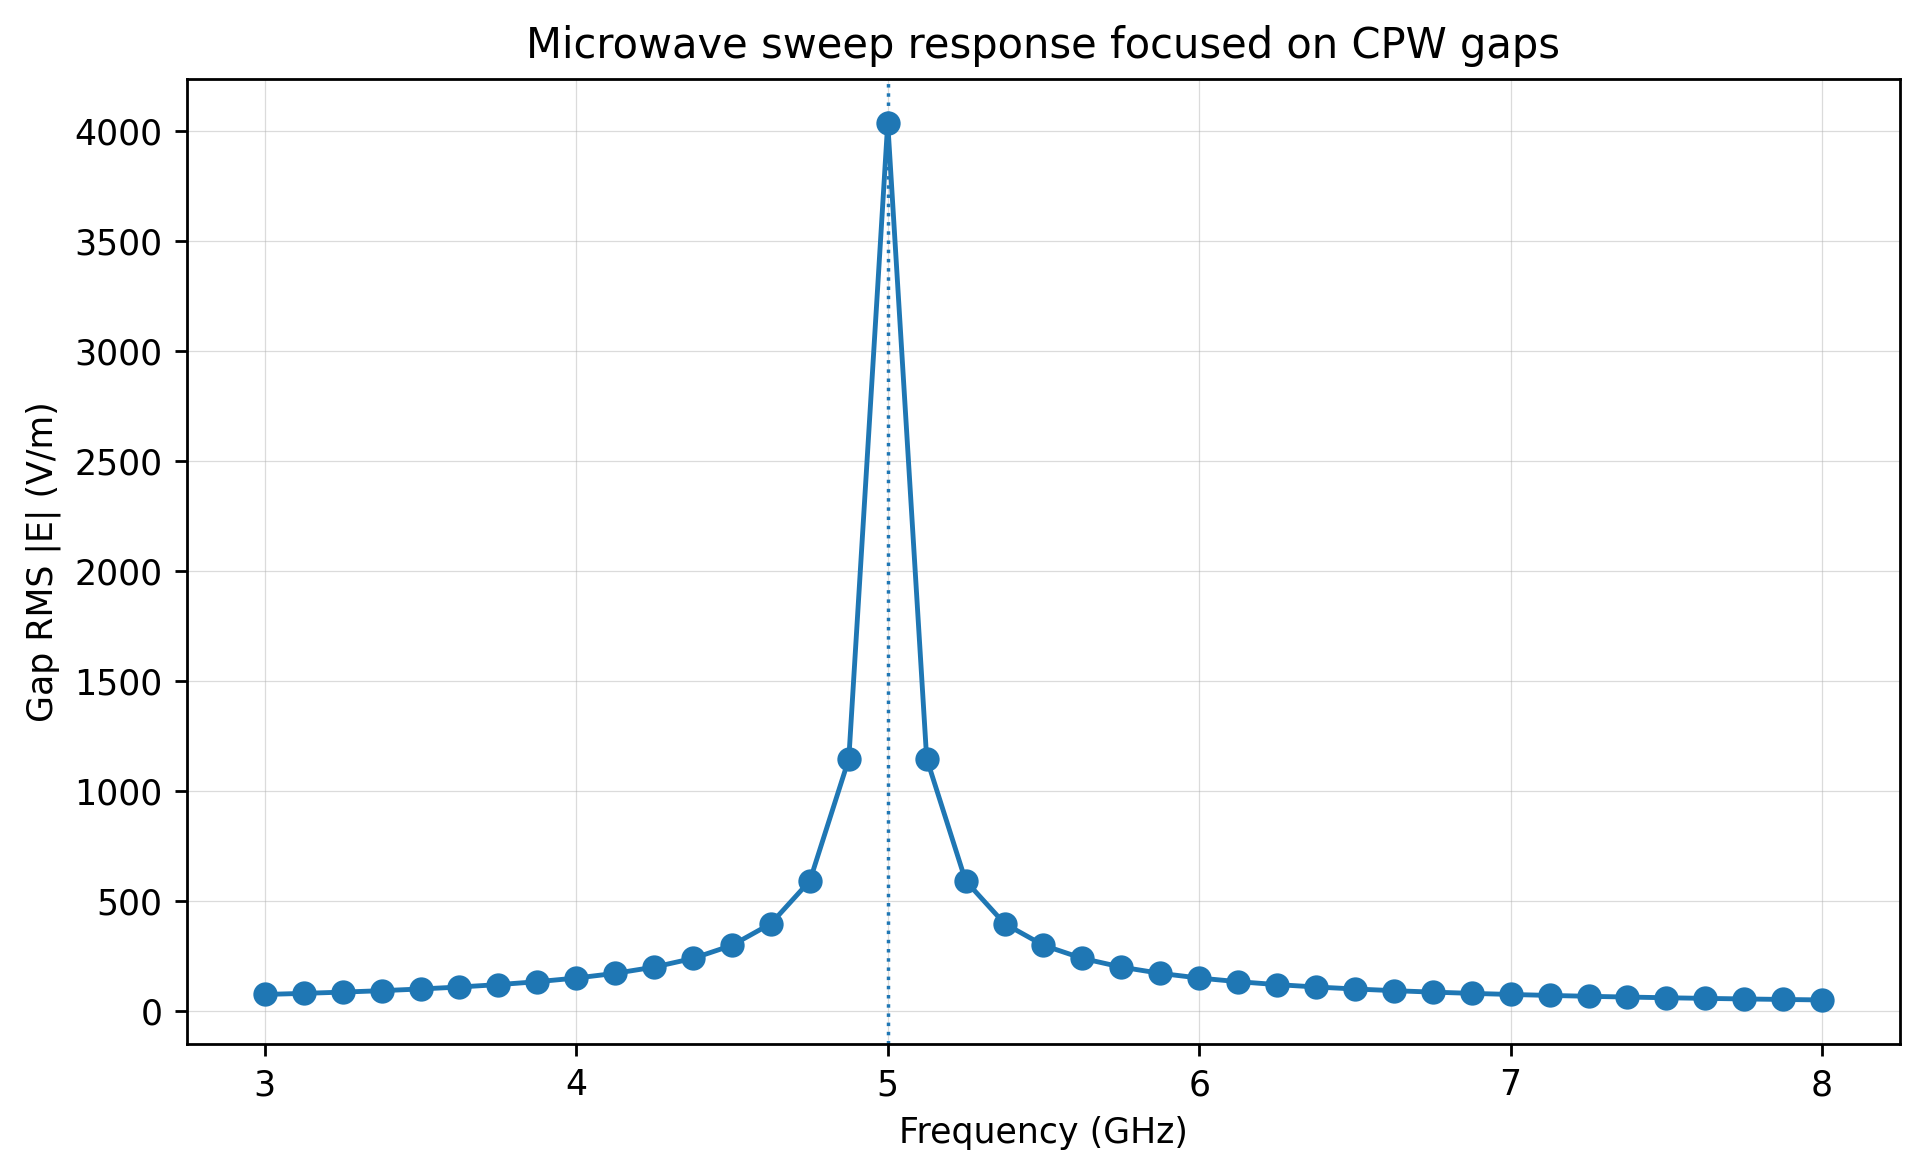

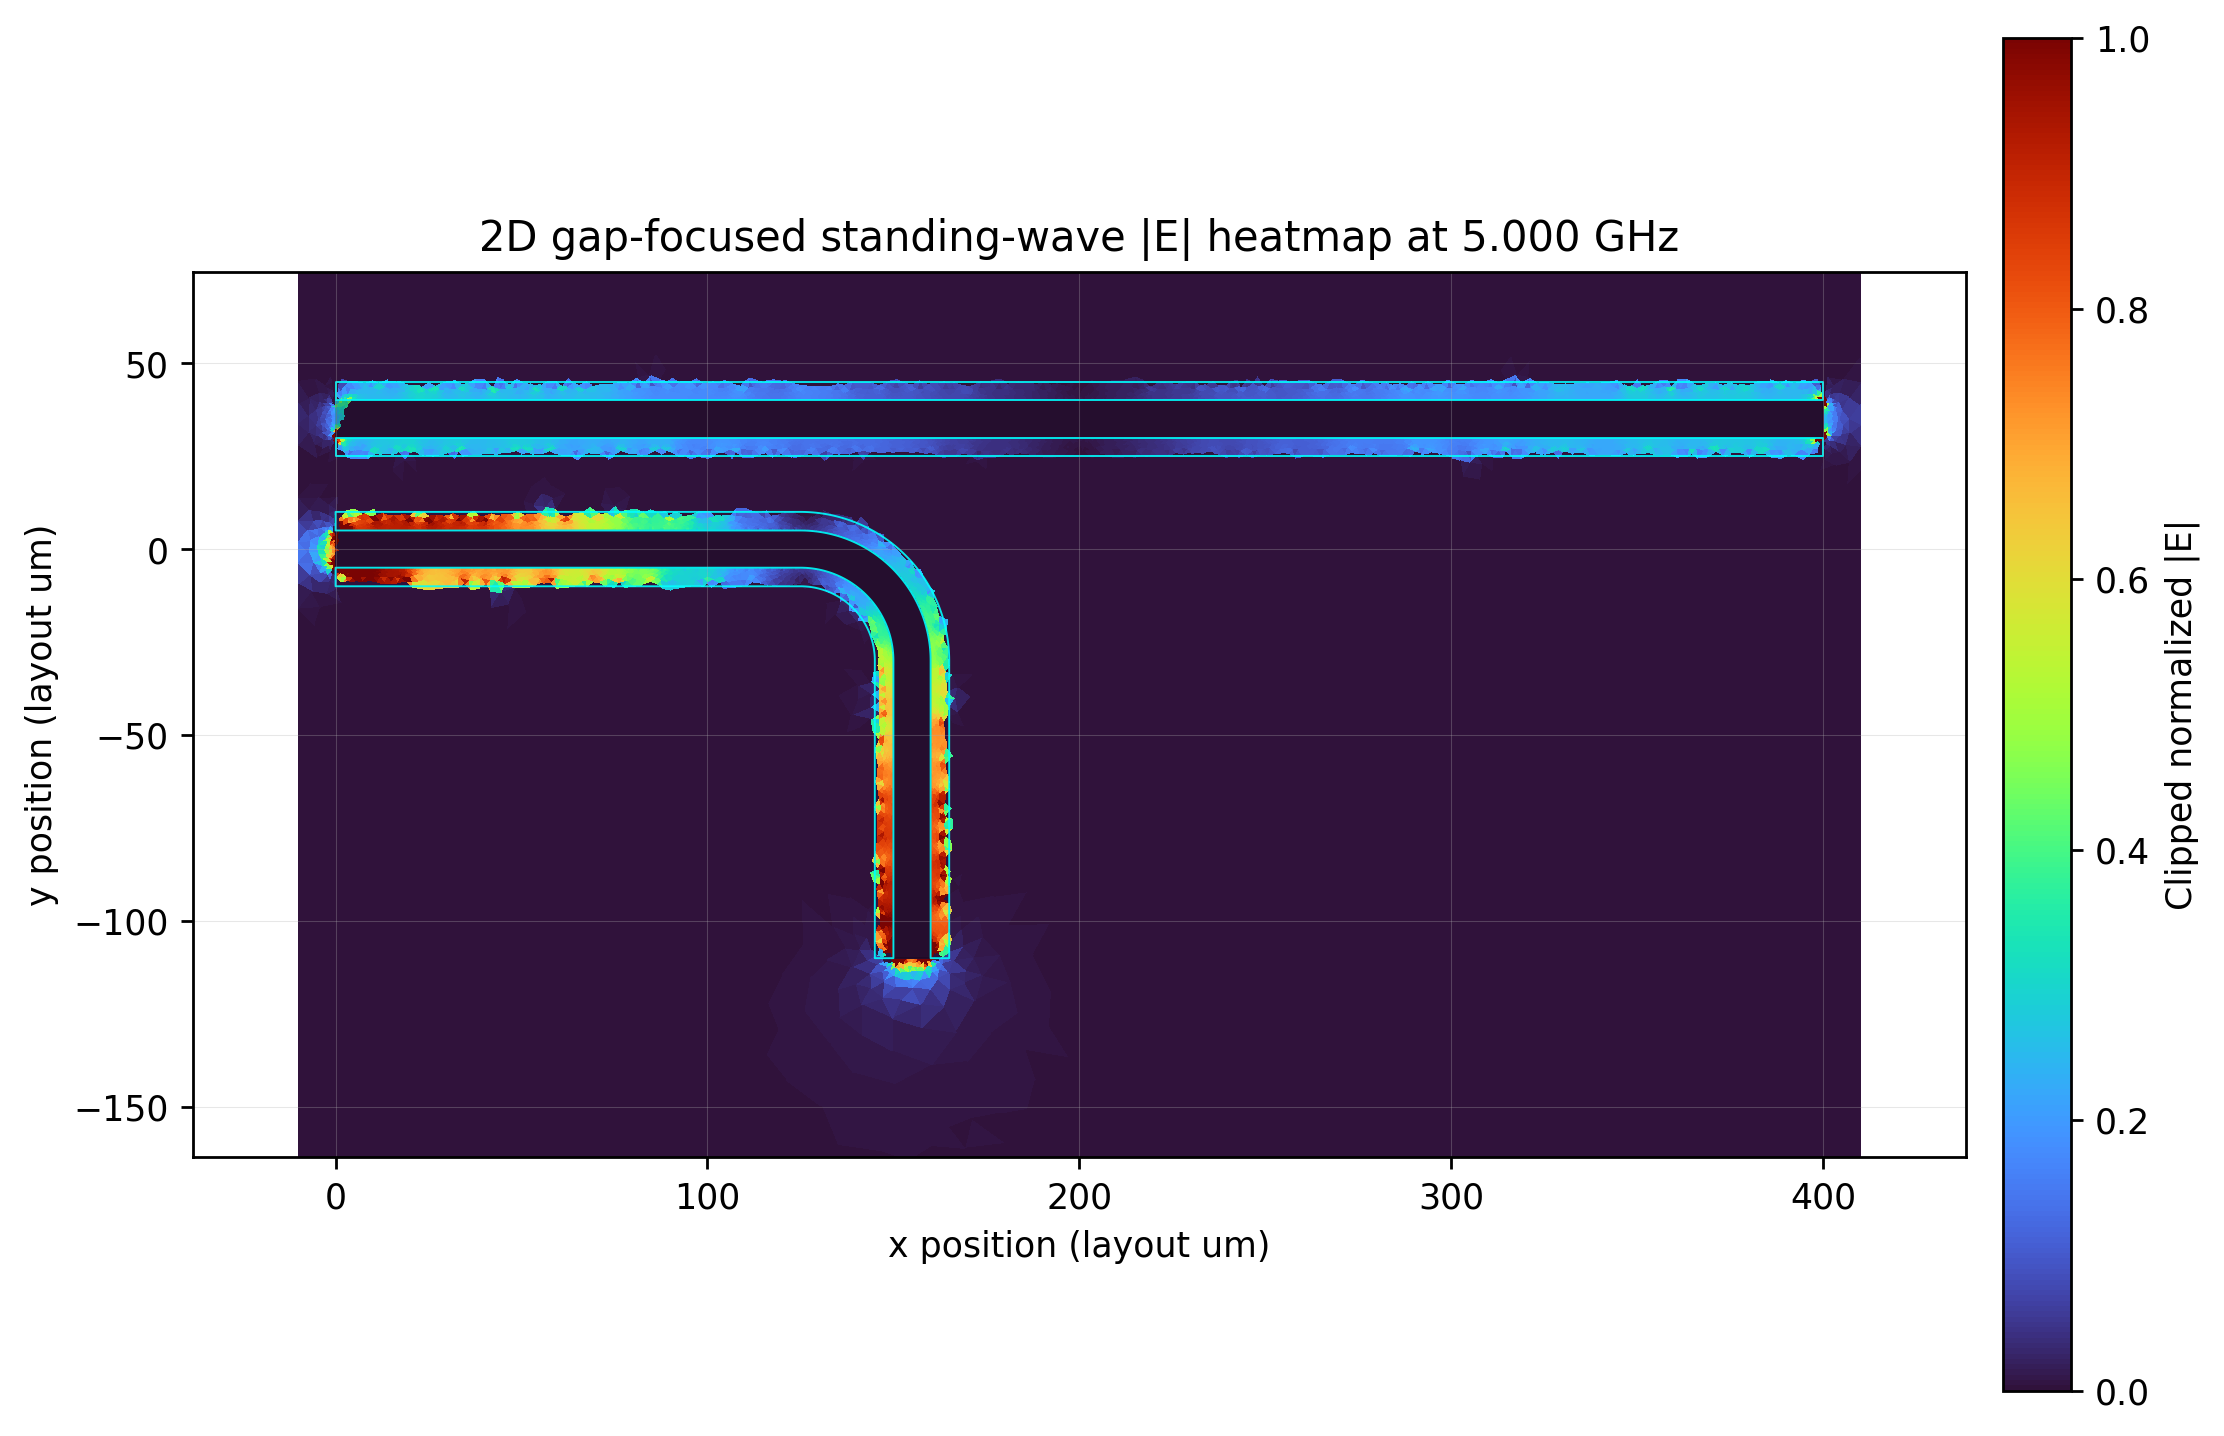

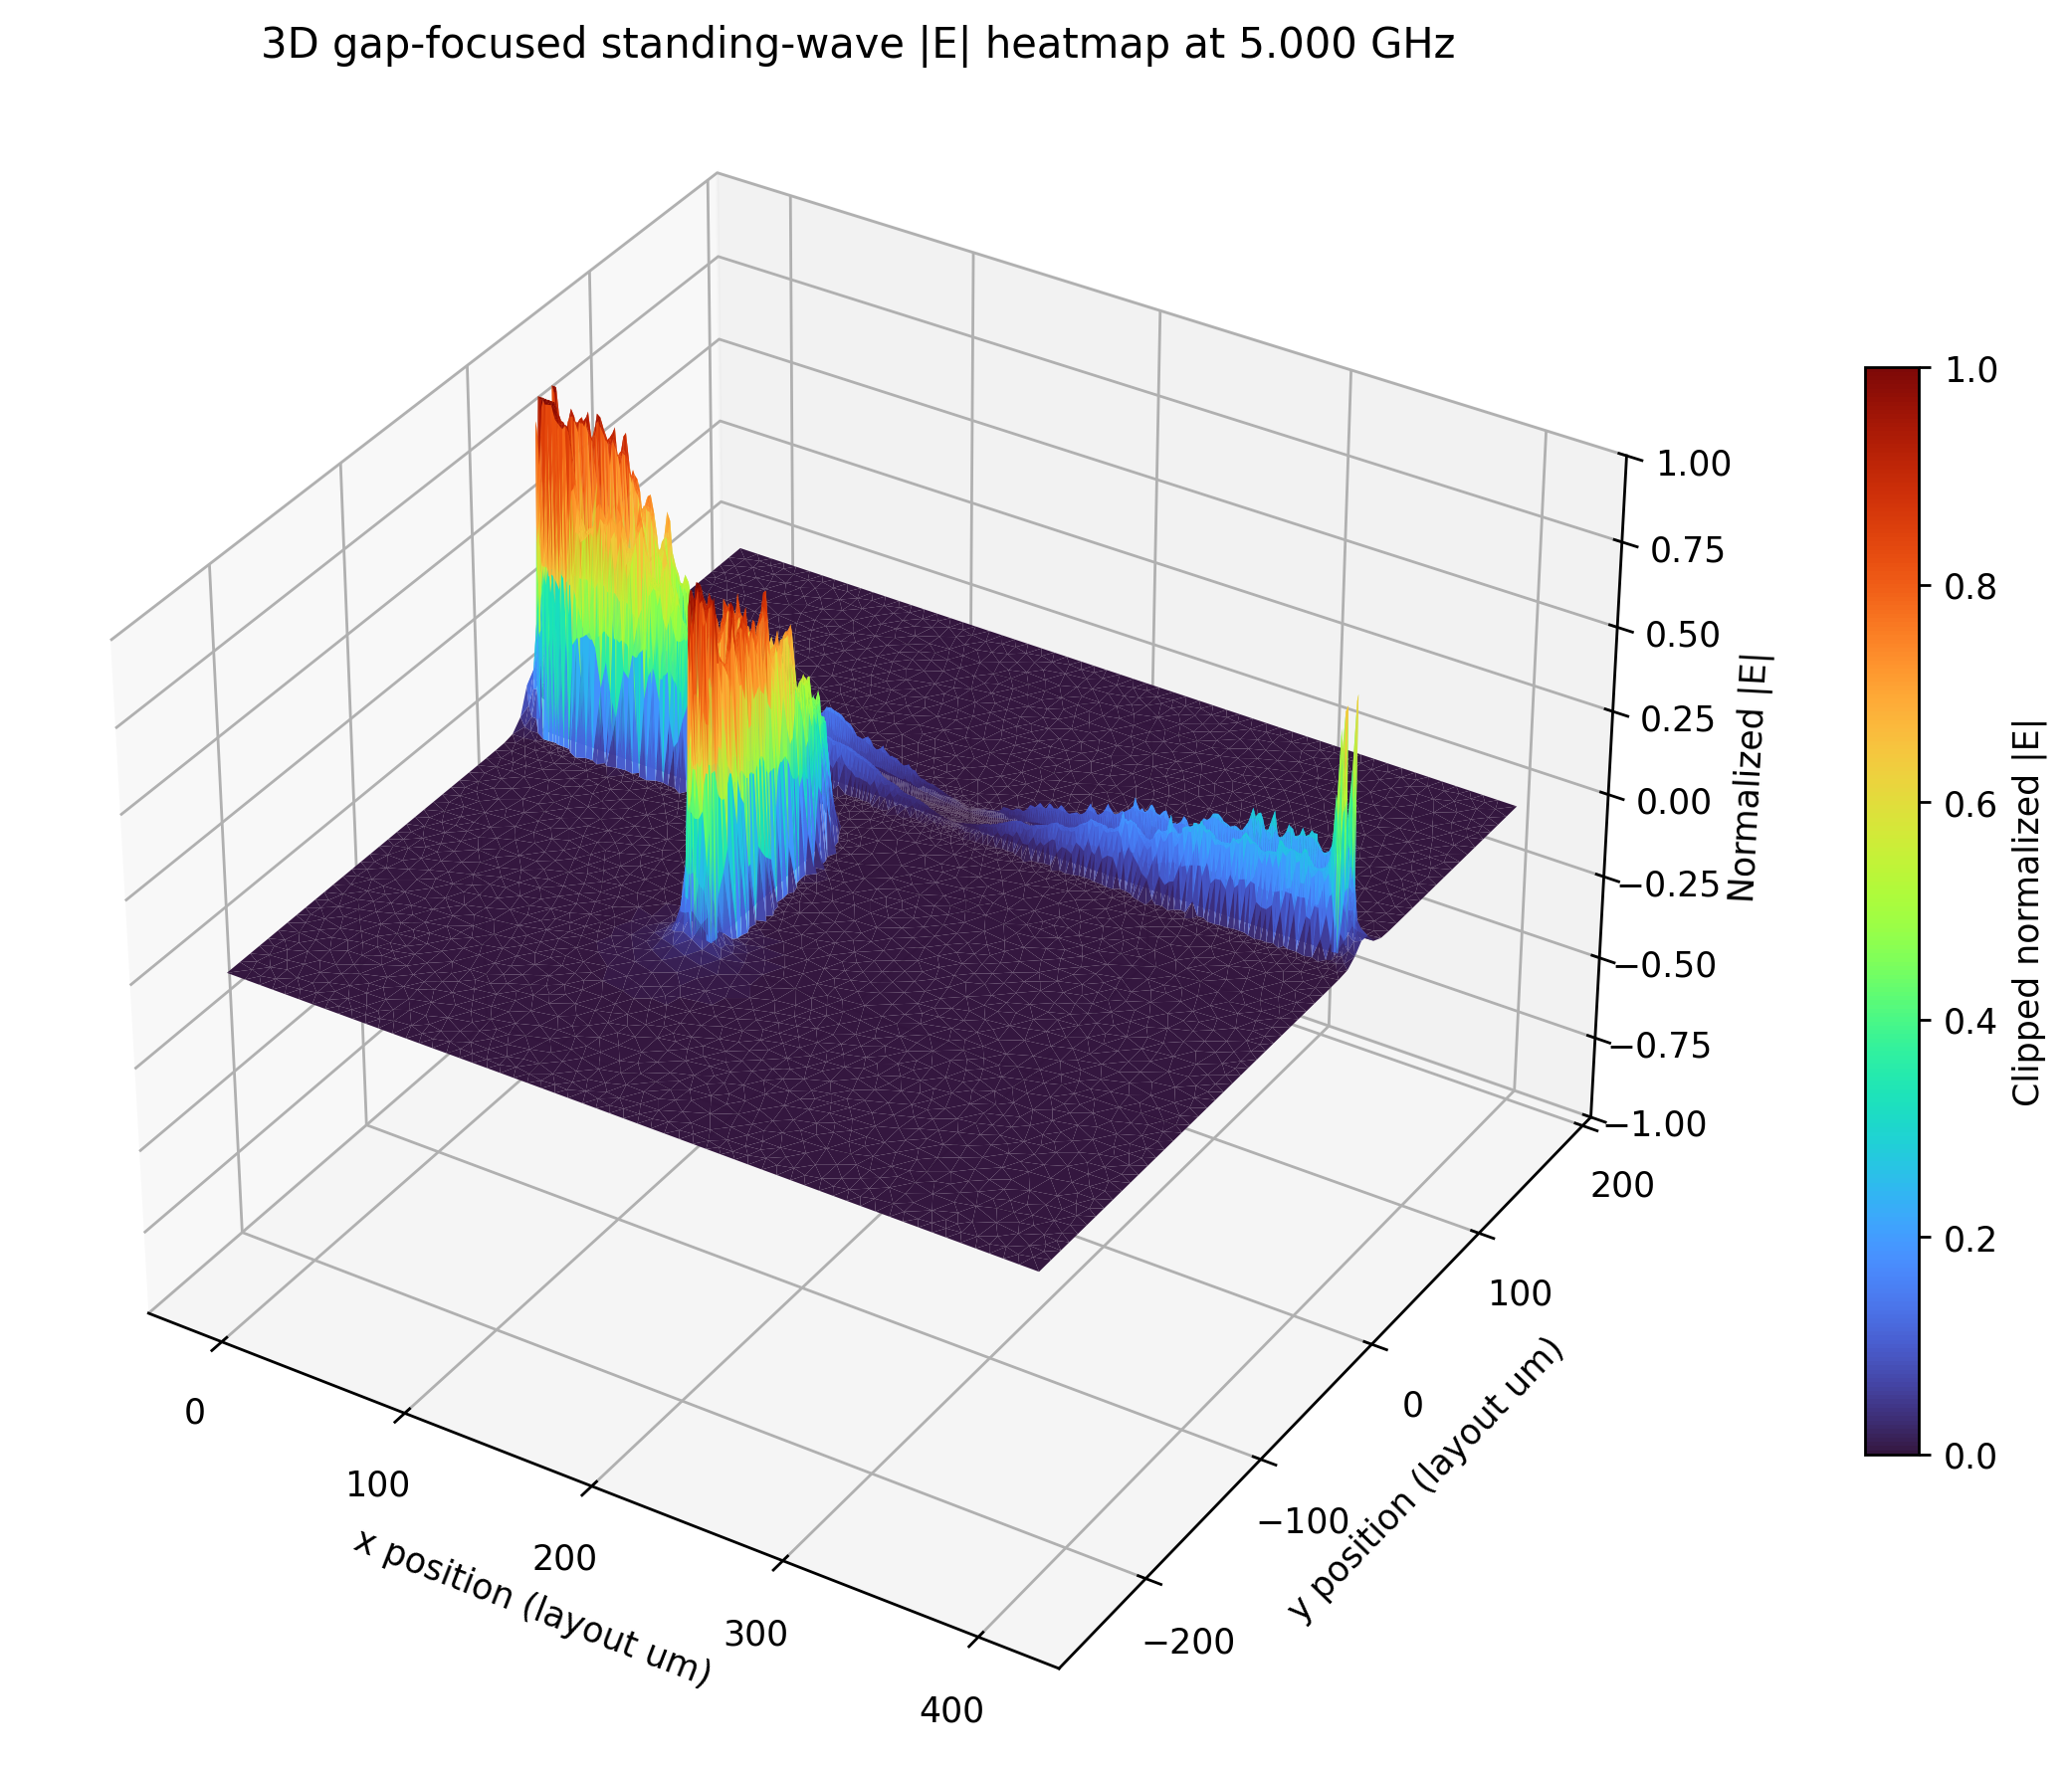

In [43]:
# Colab dependency installation.
!uv pip install --system -q scipy meshio matplotlib numpy cupy-cuda12x

"""
Gap-focused quasi-TEM FEM sweep for capacitively coupled CPW resonators.

This script uses the existing Gmsh CPW mesh and the exact PHIDL layout polygons.
It applies frequency-dependent standing-wave voltages on the CPW trace metal
surfaces, grounds the outer boundary and CPW ground-side slot edges, solves a
2D finite-element Laplace problem at each microwave sweep frequency, and plots
the electric-field norm concentrated in the CPW gaps.

The model is a quasi-TEM finite-element surrogate. It visualizes standing-wave
electric-field envelopes on CPW slots. A full vector Maxwell model requires a
3D material stack, vector basis functions, ports, conductor loss, radiation or
PML boundaries, and calibrated material properties.
"""

from dataclasses import dataclass
from pathlib import Path
from typing import Any

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import meshio
import numpy as np
from matplotlib.collections import PatchCollection
from matplotlib.path import Path as MplPath
from matplotlib.patches import Polygon as MatplotlibPolygon
from scipy.sparse import coo_matrix, csr_matrix
from scipy.sparse.linalg import splu


# =============================================================================
# CONTROL KNOBS
# =============================================================================

# Input mesh from the Gmsh block with meshed CPW trace surfaces.
MESH_INPUT_PATH = Path("faithful_cpw_boxed_gmsh_adaptive_with_trace.msh")

# Layout layers.
LAYER_TRACE = 1
LAYER_GAP = 2

# Physical scaling for electric-field units.
# The mesh coordinates are layout micrometers. This converts layout um to meters.
LAYOUT_MICROMETER_TO_PHYSICAL_METER = 25.0e-6

# Microwave sweep.
FREQUENCY_START_GHZ = 3.0
FREQUENCY_STOP_GHZ = 8.0
FREQUENCY_COUNT = 41

# Coupled-resonator response model.
DRIVE_RESONANCE_GHZ = 5.00
RESPONSE_RESONANCE_GHZ = 5.02
DRIVE_QUALITY_FACTOR = 65.0
RESPONSE_QUALITY_FACTOR = 95.0
CAPACITIVE_COUPLING_FACTOR = 0.38

# Standing-wave conductor voltage model.
DRIVE_VOLTAGE_AMPLITUDE_V = 1.0
DRIVE_MODE_INDEX = 1
RESPONSE_MODE_INDEX = 1

# Ground-node detection.
EDGE_NODE_TOLERANCE_UM = 1.25
OUTER_BOUNDARY_TOLERANCE_FRACTION = 1.0e-7
MIN_DIRICHLET_NODE_COUNT = 4

# Gap-focused response and plotting.
GAP_FIELD_REGION_RADIUS_UM = 2.20
FIELD_PERCENTILE_CLIP = 99.2
TRACE_FIELD_MASKING = True

# Plot controls.
PLOT_DPI = 250
SWEEP_FIGURE_SIZE = (7.8, 4.8)
HEATMAP_2D_FIGURE_SIZE = (9.0, 7.2)
HEATMAP_3D_FIGURE_SIZE = (9.0, 7.4)
TRISURF_TRIANGLE_LIMIT = 30_000
GEOMETRY_OVERLAY_ALPHA = 0.90

# Automatic 2D zoom controls.
AUTO_ZOOM_2D_MARGIN_FRACTION = 0.07
AUTO_ZOOM_2D_MIN_MARGIN_UM = 8.0
AUTO_ZOOM_2D_FIELD_THRESHOLD = 0.012
AUTO_ZOOM_2D_INCLUDE_ACTIVE_FIELD = True
AUTO_ZOOM_2D_LAYERS = (LAYER_TRACE, LAYER_GAP)

# 3D z-axis controls.
Z_AXIS_LOWER_LIMIT = -1.0
Z_AXIS_UPPER_LIMIT = 1.0

# Runtime diagnostics.
PRINT_SOLVE_PROGRESS = True


# =============================================================================
# DATA CONTAINERS
# =============================================================================

@dataclass(frozen=True)
class LayoutPolygon:
    """Store one exact layout polygon."""

    points_um: np.ndarray
    layer: int
    datatype: int = 0


@dataclass(frozen=True)
class MeshData:
    """Store the Gmsh mesh arrays in layout micrometer coordinates."""

    xy_um: np.ndarray
    triangles: np.ndarray


@dataclass(frozen=True)
class TraceRegions:
    """Store conductor node sets and trace polygons."""

    drive_nodes: np.ndarray
    response_nodes: np.ndarray
    drive_polygon: LayoutPolygon
    response_polygon: LayoutPolygon


@dataclass(frozen=True)
class GroundRegions:
    """Store grounded node sets."""

    outer_nodes: np.ndarray
    gap_ground_nodes: np.ndarray
    all_ground_nodes: np.ndarray


@dataclass(frozen=True)
class FemMatrices:
    """Store assembled FEM matrix data."""

    stiffness: csr_matrix
    free_nodes: np.ndarray
    dirichlet_nodes: np.ndarray
    factorization: Any


@dataclass(frozen=True)
class SweepResult:
    """Store sweep results."""

    frequencies_hz: np.ndarray
    voltages: list[np.ndarray]
    element_field_norm_v_per_m: list[np.ndarray]
    gap_response: np.ndarray
    selected_index: int


# =============================================================================
# BACKEND AND INPUT HELPERS
# =============================================================================

def configure_matplotlib() -> None:
    """Configure Matplotlib for high-resolution Colab rendering."""
    mpl.rcParams["figure.dpi"] = PLOT_DPI

    try:
        get_ipython().run_line_magic("matplotlib", "inline")
    except NameError:
        pass


def select_array_backend() -> tuple[Any, bool]:
    """Select CuPy for optional array filtering when CUDA is available."""
    try:
        import cupy as cp

        if cp.cuda.runtime.getDeviceCount() > 0:
            return cp, True

    except Exception:
        pass

    return np, False


XP, USING_CUPY = select_array_backend()


def polygon_signed_area(points_um: np.ndarray) -> float:
    """Return signed polygon area in square micrometers."""
    points = np.asarray(points_um, dtype=float)
    x_values = points[:, 0]
    y_values = points[:, 1]

    return 0.5 * float(
        np.dot(x_values, np.roll(y_values, -1))
        - np.dot(y_values, np.roll(x_values, -1))
    )


def clean_polygon(points_um: np.ndarray) -> np.ndarray:
    """Clean a polygon while preserving exact layout vertices."""
    points = np.asarray(points_um, dtype=float)

    if len(points) >= 2 and np.linalg.norm(points[0] - points[-1]) < 1.0e-12:
        points = points[:-1]

    if len(points) < 3:
        return np.empty((0, 2), dtype=float)

    area_um2 = polygon_signed_area(points)

    if abs(area_um2) < 1.0e-12:
        return np.empty((0, 2), dtype=float)

    if area_um2 < 0.0:
        points = points[::-1]

    return points


def extract_layout_polygons_from_microwave_device() -> list[LayoutPolygon]:
    """Extract trace and gap polygons from the existing PHIDL device."""
    if "microwave_device" not in globals():
        raise NameError(
            "microwave_device is missing. Run the CPW geometry cell first."
        )

    device = globals()["microwave_device"]
    polygons_by_spec = device.get_polygons(by_spec=True)
    polygons: list[LayoutPolygon] = []

    for spec, point_sets in polygons_by_spec.items():
        if isinstance(spec, tuple):
            layer = int(spec[0])
            datatype = int(spec[1]) if len(spec) > 1 else 0
        else:
            layer = int(spec)
            datatype = 0

        for point_set in point_sets:
            points = clean_polygon(np.asarray(point_set, dtype=float))
            if len(points) >= 3:
                polygons.append(
                    LayoutPolygon(
                        points_um=points,
                        layer=layer,
                        datatype=datatype,
                    )
                )

    return polygons


def get_layout_polygons() -> list[LayoutPolygon]:
    """Return layout polygons from the Gmsh mesh cell or PHIDL."""
    if "gmsh_cpw_source_polygons" in globals():
        return globals()["gmsh_cpw_source_polygons"]

    return extract_layout_polygons_from_microwave_device()


def get_mesh_data() -> MeshData:
    """Return the Gmsh mesh from memory or from a mesh file."""
    if "gmsh_cpw_mesh" in globals():
        mesh = globals()["gmsh_cpw_mesh"]
        return MeshData(
            xy_um=np.asarray(mesh.xy_coordinates_um, dtype=float),
            triangles=np.asarray(mesh.triangles, dtype=int),
        )

    if not MESH_INPUT_PATH.exists():
        raise FileNotFoundError(
            f"Mesh file was missing: {MESH_INPUT_PATH}. Run the Gmsh mesh "
            "generation block first."
        )

    meshio_mesh = meshio.read(str(MESH_INPUT_PATH))
    xy_um = np.asarray(meshio_mesh.points[:, :2], dtype=float)

    triangle_blocks = [
        cell_block.data
        for cell_block in meshio_mesh.cells
        if cell_block.type == "triangle"
    ]

    if len(triangle_blocks) == 0:
        raise RuntimeError("The mesh contains zero triangular cells.")

    triangles = np.vstack(triangle_blocks).astype(int, copy=False)

    return MeshData(xy_um=xy_um, triangles=triangles)


# =============================================================================
# GEOMETRY REGION DETECTION
# =============================================================================

def polygon_centroid(points_um: np.ndarray) -> np.ndarray:
    """Return a simple centroid based on vertex coordinates."""
    return np.mean(np.asarray(points_um, dtype=float), axis=0)


def points_inside_polygon_mask(
    points_um: np.ndarray,
    polygon_um: np.ndarray,
    radius_um: float = 0.0,
) -> np.ndarray:
    """Return a mask for points inside a polygon."""
    path = MplPath(np.asarray(polygon_um, dtype=float), closed=True)

    return path.contains_points(points_um, radius=radius_um)


def get_trace_polygons(polygons: list[LayoutPolygon]) -> list[LayoutPolygon]:
    """Return layer-1 CPW trace polygons."""
    trace_polygons = [
        polygon
        for polygon in polygons
        if polygon.layer == LAYER_TRACE
    ]

    if len(trace_polygons) < 2:
        raise RuntimeError("At least two CPW trace polygons are required.")

    return trace_polygons


def identify_trace_regions(
    mesh_data: MeshData,
    polygons: list[LayoutPolygon],
) -> TraceRegions:
    """Identify the lower drive trace and upper coupled resonator trace."""
    trace_polygons = sorted(
        get_trace_polygons(polygons),
        key=lambda polygon: polygon_centroid(polygon.points_um)[1],
    )

    drive_polygon = trace_polygons[0]
    response_polygon = trace_polygons[-1]

    drive_mask = points_inside_polygon_mask(
        mesh_data.xy_um,
        drive_polygon.points_um,
        radius_um=0.35,
    )
    response_mask = points_inside_polygon_mask(
        mesh_data.xy_um,
        response_polygon.points_um,
        radius_um=0.35,
    )

    drive_nodes = np.flatnonzero(drive_mask)
    response_nodes = np.flatnonzero(response_mask)

    if len(drive_nodes) < MIN_DIRICHLET_NODE_COUNT:
        drive_centroid = polygon_centroid(drive_polygon.points_um)
        distances = np.linalg.norm(mesh_data.xy_um - drive_centroid, axis=1)
        drive_nodes = np.argsort(distances)[:MIN_DIRICHLET_NODE_COUNT]

    if len(response_nodes) < MIN_DIRICHLET_NODE_COUNT:
        response_centroid = polygon_centroid(response_polygon.points_um)
        distances = np.linalg.norm(mesh_data.xy_um - response_centroid, axis=1)
        response_nodes = np.argsort(distances)[:MIN_DIRICHLET_NODE_COUNT]

    return TraceRegions(
        drive_nodes=np.asarray(drive_nodes, dtype=int),
        response_nodes=np.asarray(response_nodes, dtype=int),
        drive_polygon=drive_polygon,
        response_polygon=response_polygon,
    )


def polygon_segments(points_um: np.ndarray) -> np.ndarray:
    """Return closed polygon segments with shape (N, 2, 2)."""
    points = np.asarray(points_um, dtype=float)

    return np.stack([points, np.roll(points, -1, axis=0)], axis=1)


def point_to_segments_min_distance(
    points_um: np.ndarray,
    segments_um: np.ndarray,
) -> np.ndarray:
    """Return the minimum point-to-segment distance for each point."""
    points = points_um[:, None, :]
    starts = segments_um[None, :, 0, :]
    ends = segments_um[None, :, 1, :]

    segment_vectors = ends - starts
    point_vectors = points - starts

    lengths_sq = np.sum(segment_vectors**2, axis=2)
    lengths_sq = np.maximum(lengths_sq, 1.0e-30)

    projection = np.sum(point_vectors * segment_vectors, axis=2) / lengths_sq
    projection = np.clip(projection, 0.0, 1.0)

    closest = starts + projection[:, :, None] * segment_vectors
    distances = np.linalg.norm(points - closest, axis=2)

    return np.min(distances, axis=1)


def collect_gap_ground_segments(
    polygons: list[LayoutPolygon],
) -> np.ndarray:
    """
    Collect CPW ground-side gap edges.

    Gap polygons share one edge with the signal trace and one edge with the
    ground plane. The signal-coincident edge is excluded so the remaining edges
    act as grounded CPW slot boundaries.
    """
    trace_segments = []
    gap_segments = []

    for polygon in polygons:
        if polygon.layer == LAYER_TRACE:
            trace_segments.append(polygon_segments(polygon.points_um))
        elif polygon.layer == LAYER_GAP:
            gap_segments.append(polygon_segments(polygon.points_um))

    if len(gap_segments) == 0:
        return np.empty((0, 2, 2), dtype=float)

    all_gap_segments = np.concatenate(gap_segments, axis=0)

    if len(trace_segments) == 0:
        return all_gap_segments

    all_trace_segments = np.concatenate(trace_segments, axis=0)
    midpoints = 0.5 * (all_gap_segments[:, 0, :] + all_gap_segments[:, 1, :])
    distances = point_to_segments_min_distance(midpoints, all_trace_segments)

    return all_gap_segments[distances > EDGE_NODE_TOLERANCE_UM]


def find_outer_boundary_nodes(mesh_data: MeshData) -> np.ndarray:
    """Find nodes on the rectangular outer ground boundary."""
    x_values = mesh_data.xy_um[:, 0]
    y_values = mesh_data.xy_um[:, 1]

    xmin = float(np.min(x_values))
    xmax = float(np.max(x_values))
    ymin = float(np.min(y_values))
    ymax = float(np.max(y_values))

    span = max(xmax - xmin, ymax - ymin, 1.0)
    tolerance = OUTER_BOUNDARY_TOLERANCE_FRACTION * span

    mask = (
        np.isclose(x_values, xmin, atol=tolerance)
        | np.isclose(x_values, xmax, atol=tolerance)
        | np.isclose(y_values, ymin, atol=tolerance)
        | np.isclose(y_values, ymax, atol=tolerance)
    )

    return np.flatnonzero(mask)


def find_gap_ground_nodes(
    mesh_data: MeshData,
    polygons: list[LayoutPolygon],
) -> np.ndarray:
    """Find nodes close to CPW ground-side gap edges."""
    segments = collect_gap_ground_segments(polygons)

    if len(segments) == 0:
        return np.empty(0, dtype=int)

    distances = point_to_segments_min_distance(mesh_data.xy_um, segments)

    return np.flatnonzero(distances <= EDGE_NODE_TOLERANCE_UM)


def identify_ground_regions(
    mesh_data: MeshData,
    polygons: list[LayoutPolygon],
    trace_regions: TraceRegions,
) -> GroundRegions:
    """Identify grounded outer and slot-edge nodes."""
    outer_nodes = find_outer_boundary_nodes(mesh_data)
    gap_ground_nodes = find_gap_ground_nodes(mesh_data, polygons)

    trace_nodes = np.union1d(
        trace_regions.drive_nodes,
        trace_regions.response_nodes,
    )
    gap_ground_nodes = np.setdiff1d(gap_ground_nodes, trace_nodes)

    all_ground_nodes = np.union1d(outer_nodes, gap_ground_nodes)

    return GroundRegions(
        outer_nodes=outer_nodes,
        gap_ground_nodes=gap_ground_nodes,
        all_ground_nodes=all_ground_nodes,
    )


# =============================================================================
# STANDING-WAVE TRACE VOLTAGE MODEL
# =============================================================================

def get_global_float(name: str, default: float) -> float:
    """Return a global control value when available."""
    return float(globals().get(name, default))


def sample_elbow_centerline() -> tuple[np.ndarray, np.ndarray]:
    """Sample the lower elbow CPW centerline and cumulative path coordinate."""
    parallel_length_um = get_global_float("ELBOW_PARALLEL_ARM_LENGTH_UM", 125.0)
    bend_radius_um = get_global_float("ELBOW_BEND_RADIUS_UM", 30.0)
    vertical_length_um = get_global_float(
        "ELBOW_PERPENDICULAR_ARM_LENGTH_UM",
        80.0,
    )

    horizontal_count = 160
    arc_count = 120
    vertical_count = 120

    x_horizontal = np.linspace(0.0, parallel_length_um, horizontal_count)
    y_horizontal = np.zeros_like(x_horizontal)

    theta = np.linspace(np.pi / 2.0, 0.0, arc_count)
    x_arc = parallel_length_um + bend_radius_um * np.cos(theta)
    y_arc = -bend_radius_um + bend_radius_um * np.sin(theta)

    x_vertical = np.full(vertical_count, parallel_length_um + bend_radius_um)
    y_vertical = np.linspace(
        -bend_radius_um,
        -bend_radius_um - vertical_length_um,
        vertical_count,
    )

    points = np.column_stack(
        [
            np.concatenate([x_horizontal, x_arc[1:], x_vertical[1:]]),
            np.concatenate([y_horizontal, y_arc[1:], y_vertical[1:]]),
        ]
    )

    increments = np.linalg.norm(np.diff(points, axis=0), axis=1)
    path_coordinate = np.concatenate([[0.0], np.cumsum(increments)])

    return points, path_coordinate


def nearest_path_coordinate(
    points_um: np.ndarray,
    centerline_um: np.ndarray,
    centerline_s_um: np.ndarray,
) -> tuple[np.ndarray, float]:
    """Map points to the nearest sampled centerline coordinate."""
    deltas = points_um[:, None, :] - centerline_um[None, :, :]
    distances_sq = np.sum(deltas**2, axis=2)
    nearest_indices = np.argmin(distances_sq, axis=1)

    return centerline_s_um[nearest_indices], float(centerline_s_um[-1])


def straight_path_coordinate(
    points_um: np.ndarray,
    polygon: LayoutPolygon,
) -> tuple[np.ndarray, float]:
    """Map points on a straight trace to x-directed path coordinate."""
    x_min = float(np.min(polygon.points_um[:, 0]))
    x_max = float(np.max(polygon.points_um[:, 0]))
    length_um = max(x_max - x_min, 1.0e-12)
    s_um = np.clip(points_um[:, 0] - x_min, 0.0, length_um)

    return s_um, length_um


def standing_wave_profile(
    s_um: np.ndarray,
    length_um: float,
    mode_index: int,
) -> np.ndarray:
    """Return an open-ended standing-wave voltage profile."""
    coordinate = np.clip(s_um / max(length_um, 1.0e-12), 0.0, 1.0)

    return np.cos(mode_index * np.pi * coordinate)


def coupled_mode_amplitudes(frequency_hz: float) -> tuple[complex, complex]:
    """Return complex drive and coupled-resonator amplitudes."""
    frequency_ghz = frequency_hz / 1.0e9

    drive_detuning = (frequency_ghz - DRIVE_RESONANCE_GHZ) / DRIVE_RESONANCE_GHZ
    response_detuning = (
        (frequency_ghz - RESPONSE_RESONANCE_GHZ) / RESPONSE_RESONANCE_GHZ
    )

    drive_amplitude = 1.0 / (1.0 + 2.0j * DRIVE_QUALITY_FACTOR * drive_detuning)
    response_amplitude = (
        CAPACITIVE_COUPLING_FACTOR
        * drive_amplitude
        / (1.0 + 2.0j * RESPONSE_QUALITY_FACTOR * response_detuning)
    )

    return drive_amplitude, response_amplitude


def build_dirichlet_values(
    mesh_data: MeshData,
    trace_regions: TraceRegions,
    ground_regions: GroundRegions,
    frequency_hz: float,
) -> tuple[np.ndarray, np.ndarray]:
    """Build complex Dirichlet node indices and values for one frequency."""
    voltage = np.zeros(len(mesh_data.xy_um), dtype=np.complex128)

    drive_amplitude, response_amplitude = coupled_mode_amplitudes(frequency_hz)

    centerline_um, centerline_s_um = sample_elbow_centerline()
    drive_points = mesh_data.xy_um[trace_regions.drive_nodes]
    drive_s_um, drive_length_um = nearest_path_coordinate(
        points_um=drive_points,
        centerline_um=centerline_um,
        centerline_s_um=centerline_s_um,
    )
    drive_profile = standing_wave_profile(
        s_um=drive_s_um,
        length_um=drive_length_um,
        mode_index=DRIVE_MODE_INDEX,
    )

    response_points = mesh_data.xy_um[trace_regions.response_nodes]
    response_s_um, response_length_um = straight_path_coordinate(
        points_um=response_points,
        polygon=trace_regions.response_polygon,
    )
    response_profile = standing_wave_profile(
        s_um=response_s_um,
        length_um=response_length_um,
        mode_index=RESPONSE_MODE_INDEX,
    )

    voltage[ground_regions.all_ground_nodes] = 0.0 + 0.0j
    voltage[trace_regions.drive_nodes] = (
        DRIVE_VOLTAGE_AMPLITUDE_V * drive_amplitude * drive_profile
    )
    voltage[trace_regions.response_nodes] = (
        DRIVE_VOLTAGE_AMPLITUDE_V * response_amplitude * response_profile
    )

    dirichlet_nodes = np.union1d(
        ground_regions.all_ground_nodes,
        np.union1d(trace_regions.drive_nodes, trace_regions.response_nodes),
    )

    return dirichlet_nodes, voltage[dirichlet_nodes]


# =============================================================================
# FEM ASSEMBLY AND SOLVE
# =============================================================================

def assemble_laplace_stiffness(mesh_data: MeshData) -> csr_matrix:
    """Assemble the scalar P1 triangular Laplace stiffness matrix."""
    points_m = mesh_data.xy_um * LAYOUT_MICROMETER_TO_PHYSICAL_METER
    triangles = mesh_data.triangles

    rows = []
    cols = []
    values = []

    for triangle in triangles:
        coords = points_m[triangle]
        x0, y0 = coords[0]
        x1, y1 = coords[1]
        x2, y2 = coords[2]

        twice_area = (x1 - x0) * (y2 - y0) - (x2 - x0) * (y1 - y0)
        area = 0.5 * abs(twice_area)

        if area <= 0.0:
            continue

        b_values = np.array([y1 - y2, y2 - y0, y0 - y1], dtype=float)
        c_values = np.array([x2 - x1, x0 - x2, x1 - x0], dtype=float)

        local = (
            np.outer(b_values, b_values)
            + np.outer(c_values, c_values)
        ) / (4.0 * area)

        for local_i, global_i in enumerate(triangle):
            for local_j, global_j in enumerate(triangle):
                rows.append(int(global_i))
                cols.append(int(global_j))
                values.append(local[local_i, local_j])

    node_count = len(mesh_data.xy_um)

    return coo_matrix(
        (values, (rows, cols)),
        shape=(node_count, node_count),
    ).tocsr()


def build_fem_matrices(
    stiffness: csr_matrix,
    dirichlet_nodes: np.ndarray,
) -> FemMatrices:
    """Build complex-valued free-node factorization for fixed Dirichlet nodes."""
    node_count = stiffness.shape[0]
    all_nodes = np.arange(node_count, dtype=int)
    dirichlet_nodes = np.unique(dirichlet_nodes.astype(int, copy=False))
    free_nodes = np.setdiff1d(all_nodes, dirichlet_nodes)

    free_stiffness = stiffness[free_nodes][:, free_nodes]
    free_stiffness = free_stiffness.astype(np.complex128).tocsc()
    factorization = splu(free_stiffness)

    return FemMatrices(
        stiffness=stiffness.astype(np.complex128).tocsr(),
        free_nodes=free_nodes,
        dirichlet_nodes=dirichlet_nodes,
        factorization=factorization,
    )


def solve_dirichlet_problem(
    fem: FemMatrices,
    dirichlet_values: np.ndarray,
) -> np.ndarray:
    """Solve the finite-element Laplace problem with complex Dirichlet data."""
    node_count = fem.stiffness.shape[0]
    solution = np.zeros(node_count, dtype=np.complex128)
    dirichlet_values = np.asarray(dirichlet_values, dtype=np.complex128)

    solution[fem.dirichlet_nodes] = dirichlet_values

    rhs = -fem.stiffness[fem.free_nodes][:, fem.dirichlet_nodes] @ dirichlet_values
    rhs = np.asarray(rhs, dtype=np.complex128)

    solution[fem.free_nodes] = fem.factorization.solve(rhs)

    return solution


def triangle_gradients(
    mesh_data: MeshData,
    potential: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Compute elementwise electric field components and norm."""
    points_m = mesh_data.xy_um * LAYOUT_MICROMETER_TO_PHYSICAL_METER
    triangles = mesh_data.triangles

    ex_values = np.zeros(len(triangles), dtype=np.complex128)
    ey_values = np.zeros(len(triangles), dtype=np.complex128)

    for element_index, triangle in enumerate(triangles):
        coords = points_m[triangle]
        values = potential[triangle]

        x0, y0 = coords[0]
        x1, y1 = coords[1]
        x2, y2 = coords[2]

        twice_area = (x1 - x0) * (y2 - y0) - (x2 - x0) * (y1 - y0)

        if abs(twice_area) <= 0.0:
            continue

        b_values = np.array([y1 - y2, y2 - y0, y0 - y1], dtype=float)
        c_values = np.array([x2 - x1, x0 - x2, x1 - x0], dtype=float)

        grad_x = np.dot(values, b_values) / twice_area
        grad_y = np.dot(values, c_values) / twice_area

        ex_values[element_index] = -grad_x
        ey_values[element_index] = -grad_y

    field_norm = np.sqrt(np.abs(ex_values) ** 2 + np.abs(ey_values) ** 2)

    return ex_values, ey_values, field_norm


def triangle_centroids(mesh_data: MeshData) -> np.ndarray:
    """Return element centroid coordinates in layout micrometers."""
    return mesh_data.xy_um[mesh_data.triangles].mean(axis=1)


def element_mask_inside_trace(
    mesh_data: MeshData,
    polygons: list[LayoutPolygon],
) -> np.ndarray:
    """Return mask for elements whose centroids are inside trace metal."""
    centroids = triangle_centroids(mesh_data)
    inside_trace = np.zeros(len(mesh_data.triangles), dtype=bool)

    for polygon in polygons:
        if polygon.layer == LAYER_TRACE:
            inside_trace |= points_inside_polygon_mask(
                centroids,
                polygon.points_um,
                radius_um=0.20,
            )

    return inside_trace


def element_mask_near_gaps(
    mesh_data: MeshData,
    polygons: list[LayoutPolygon],
) -> np.ndarray:
    """Return mask for elements near CPW gap polygons."""
    centroids = triangle_centroids(mesh_data)
    gap_segments = []

    for polygon in polygons:
        if polygon.layer == LAYER_GAP:
            gap_segments.append(polygon_segments(polygon.points_um))

    if len(gap_segments) == 0:
        return np.ones(len(mesh_data.triangles), dtype=bool)

    segments = np.concatenate(gap_segments, axis=0)
    distances = point_to_segments_min_distance(centroids, segments)

    return distances <= GAP_FIELD_REGION_RADIUS_UM


def element_to_node_average(
    mesh_data: MeshData,
    element_values: np.ndarray,
) -> np.ndarray:
    """Average element values to mesh nodes for 3D surface plotting."""
    node_count = len(mesh_data.xy_um)
    totals = np.zeros(node_count, dtype=float)
    counts = np.zeros(node_count, dtype=float)

    for triangle, value in zip(mesh_data.triangles, element_values):
        totals[triangle] += value
        counts[triangle] += 1.0

    counts = np.maximum(counts, 1.0)

    return totals / counts


def normalize_field_for_plot(field: np.ndarray) -> np.ndarray:
    """Clip and normalize a field array for visualization."""
    finite_values = field[np.isfinite(field)]

    if len(finite_values) == 0:
        return np.zeros_like(field)

    clip_value = np.percentile(finite_values, FIELD_PERCENTILE_CLIP)
    clip_value = max(float(clip_value), 1.0e-30)

    return np.clip(field / clip_value, 0.0, 1.0)


def run_frequency_sweep(
    mesh_data: MeshData,
    polygons: list[LayoutPolygon],
    trace_regions: TraceRegions,
    ground_regions: GroundRegions,
) -> SweepResult:
    """Run the microwave sweep with standing-wave conductor voltages."""
    frequencies_hz = np.linspace(
        FREQUENCY_START_GHZ * 1.0e9,
        FREQUENCY_STOP_GHZ * 1.0e9,
        FREQUENCY_COUNT,
    )

    first_dirichlet_nodes, _ = build_dirichlet_values(
        mesh_data=mesh_data,
        trace_regions=trace_regions,
        ground_regions=ground_regions,
        frequency_hz=frequencies_hz[0],
    )

    stiffness = assemble_laplace_stiffness(mesh_data)
    fem = build_fem_matrices(
        stiffness=stiffness,
        dirichlet_nodes=first_dirichlet_nodes,
    )

    trace_element_mask = element_mask_inside_trace(mesh_data, polygons)
    gap_element_mask = element_mask_near_gaps(mesh_data, polygons)

    potentials = []
    field_norms = []
    gap_response = []

    for index, frequency_hz in enumerate(frequencies_hz):
        dirichlet_nodes, dirichlet_values = build_dirichlet_values(
            mesh_data=mesh_data,
            trace_regions=trace_regions,
            ground_regions=ground_regions,
            frequency_hz=frequency_hz,
        )

        if not np.array_equal(dirichlet_nodes, fem.dirichlet_nodes):
            raise RuntimeError("Dirichlet node set changed during the sweep.")

        potential = solve_dirichlet_problem(
            fem=fem,
            dirichlet_values=dirichlet_values,
        )
        _, _, field_norm = triangle_gradients(
            mesh_data=mesh_data,
            potential=potential,
        )

        if TRACE_FIELD_MASKING:
            field_norm = field_norm.copy()
            field_norm[trace_element_mask] = 0.0

        response = np.sqrt(np.mean(field_norm[gap_element_mask] ** 2))

        potentials.append(potential)
        field_norms.append(field_norm)
        gap_response.append(response)

        if PRINT_SOLVE_PROGRESS:
            print(
                f"[{index + 1:02d}/{len(frequencies_hz):02d}] "
                f"f = {frequency_hz / 1.0e9:.3f} GHz, "
                f"gap RMS |E| = {response:.4e} V/m"
            )

    gap_response_array = np.asarray(gap_response, dtype=float)
    selected_index = int(np.argmax(gap_response_array))

    return SweepResult(
        frequencies_hz=frequencies_hz,
        voltages=potentials,
        element_field_norm_v_per_m=field_norms,
        gap_response=gap_response_array,
        selected_index=selected_index,
    )


# =============================================================================
# PLOTTING
# =============================================================================

def plot_sweep_response(sweep: SweepResult) -> None:
    """Plot gap electric-field response over frequency."""
    frequency_ghz = sweep.frequencies_hz / 1.0e9

    _, axis = plt.subplots(figsize=SWEEP_FIGURE_SIZE)
    axis.plot(
        frequency_ghz,
        sweep.gap_response,
        marker="o",
        linewidth=1.4,
    )
    axis.axvline(
        frequency_ghz[sweep.selected_index],
        linestyle=":",
        linewidth=1.0,
    )
    axis.set_xlabel("Frequency (GHz)")
    axis.set_ylabel("Gap RMS |E| (V/m)")
    axis.set_title("Microwave sweep response focused on CPW gaps")
    axis.grid(True, linewidth=0.35, alpha=0.45)
    plt.tight_layout()
    plt.show()


def overlay_layout_edges(
    axis: plt.Axes,
    polygons: list[LayoutPolygon],
) -> None:
    """Overlay CPW trace and gap geometry on field plots."""
    gap_patches = []

    for polygon in polygons:
        if polygon.layer == LAYER_TRACE:
            axis.add_patch(
                MatplotlibPolygon(
                    polygon.points_um,
                    closed=True,
                    facecolor="black",
                    edgecolor="black",
                    linewidth=0.50,
                    alpha=0.22,
                )
            )
        elif polygon.layer == LAYER_GAP:
            gap_patches.append(MatplotlibPolygon(polygon.points_um, closed=True))

    if gap_patches:
        axis.add_collection(
            PatchCollection(
                gap_patches,
                facecolor="none",
                edgecolor="cyan",
                linewidths=0.55,
                alpha=GEOMETRY_OVERLAY_ALPHA,
            )
        )


def get_bounds_from_points(
    points_um: np.ndarray,
) -> tuple[float, float, float, float]:
    """Return xmin, xmax, ymin, ymax bounds from point coordinates."""
    points = np.asarray(points_um, dtype=float)

    return (
        float(np.min(points[:, 0])),
        float(np.max(points[:, 0])),
        float(np.min(points[:, 1])),
        float(np.max(points[:, 1])),
    )


def get_polygon_bounds(
    polygons: list[LayoutPolygon],
) -> tuple[float, float, float, float] | None:
    """Return bounds around CPW trace and gap polygons."""
    point_sets = [
        polygon.points_um
        for polygon in polygons
        if polygon.layer in AUTO_ZOOM_2D_LAYERS and len(polygon.points_um) >= 3
    ]

    if len(point_sets) == 0:
        return None

    return get_bounds_from_points(np.vstack(point_sets))


def get_active_field_bounds(
    mesh_data: MeshData,
    field_norm: np.ndarray,
) -> tuple[float, float, float, float] | None:
    """Return bounds around elements with visible normalized field."""
    field_normalized = normalize_field_for_plot(field_norm)

    if len(field_normalized) == len(mesh_data.triangles):
        centroids_um = mesh_data.xy_um[mesh_data.triangles].mean(axis=1)
        active_points = centroids_um[
            field_normalized >= AUTO_ZOOM_2D_FIELD_THRESHOLD
        ]
    elif len(field_normalized) == len(mesh_data.xy_um):
        active_points = mesh_data.xy_um[
            field_normalized >= AUTO_ZOOM_2D_FIELD_THRESHOLD
        ]
    else:
        return None

    if len(active_points) == 0:
        return None

    return get_bounds_from_points(active_points)


def merge_bounds(
    bounds_list: list[tuple[float, float, float, float] | None],
) -> tuple[float, float, float, float]:
    """Merge several xmin, xmax, ymin, ymax bounds."""
    valid_bounds = [bounds for bounds in bounds_list if bounds is not None]

    if len(valid_bounds) == 0:
        raise ValueError("No valid bounds were available for automatic zoom.")

    xmin = min(bounds[0] for bounds in valid_bounds)
    xmax = max(bounds[1] for bounds in valid_bounds)
    ymin = min(bounds[2] for bounds in valid_bounds)
    ymax = max(bounds[3] for bounds in valid_bounds)

    return xmin, xmax, ymin, ymax


def expand_bounds(
    bounds: tuple[float, float, float, float],
) -> tuple[float, float, float, float]:
    """Expand bounds by a controlled margin."""
    xmin, xmax, ymin, ymax = bounds

    span_x = max(xmax - xmin, 1.0)
    span_y = max(ymax - ymin, 1.0)
    margin_um = max(
        AUTO_ZOOM_2D_MIN_MARGIN_UM,
        AUTO_ZOOM_2D_MARGIN_FRACTION * max(span_x, span_y),
    )

    return (
        xmin - margin_um,
        xmax + margin_um,
        ymin - margin_um,
        ymax + margin_um,
    )


def compute_2d_auto_zoom_bounds(
    mesh_data: MeshData,
    polygons: list[LayoutPolygon],
    field_norm: np.ndarray | None = None,
) -> tuple[float, float, float, float]:
    """Compute tight 2D plot limits around CPW geometry and active field."""
    bounds_sources = [get_polygon_bounds(polygons)]

    if AUTO_ZOOM_2D_INCLUDE_ACTIVE_FIELD and field_norm is not None:
        bounds_sources.append(
            get_active_field_bounds(
                mesh_data=mesh_data,
                field_norm=field_norm,
            )
        )

    return expand_bounds(merge_bounds(bounds_sources))


def set_cpw_zoom(
    axis: plt.Axes,
    mesh_data: MeshData,
    polygons: list[LayoutPolygon],
    field_norm: np.ndarray,
) -> None:
    """Set tight 2D plot limits around the plotted CPW items."""
    xmin, xmax, ymin, ymax = compute_2d_auto_zoom_bounds(
        mesh_data=mesh_data,
        polygons=polygons,
        field_norm=field_norm,
    )

    axis.set_xlim(xmin, xmax)
    axis.set_ylim(ymin, ymax)


def plot_2d_gap_heatmap(
    mesh_data: MeshData,
    polygons: list[LayoutPolygon],
    field_norm: np.ndarray,
    frequency_hz: float,
) -> None:
    """Render a 2D heatmap with automatic tight zoom around plotted items."""
    triangulation = mtri.Triangulation(
        mesh_data.xy_um[:, 0],
        mesh_data.xy_um[:, 1],
        mesh_data.triangles,
    )

    field_normalized = normalize_field_for_plot(field_norm)

    _, axis = plt.subplots(figsize=HEATMAP_2D_FIGURE_SIZE)
    image = axis.tripcolor(
        triangulation,
        facecolors=field_normalized,
        shading="flat",
        cmap="turbo",
    )

    overlay_layout_edges(axis, polygons)
    set_cpw_zoom(
        axis=axis,
        mesh_data=mesh_data,
        polygons=polygons,
        field_norm=field_norm,
    )

    axis.set_aspect("equal", adjustable="box")
    axis.set_xlabel("x position (layout um)")
    axis.set_ylabel("y position (layout um)")
    axis.set_title(
        "2D gap-focused standing-wave |E| heatmap at "
        f"{frequency_hz / 1.0e9:.3f} GHz"
    )
    axis.grid(True, linewidth=0.30, alpha=0.30)

    colorbar = plt.colorbar(image, ax=axis, fraction=0.036, pad=0.02)
    colorbar.set_label("Clipped normalized |E|")

    plt.tight_layout()
    plt.show()


def decimate_triangles_for_3d(triangles: np.ndarray) -> np.ndarray:
    """Decimate triangles for responsive 3D plotting."""
    if len(triangles) <= TRISURF_TRIANGLE_LIMIT:
        return triangles

    stride = int(np.ceil(len(triangles) / TRISURF_TRIANGLE_LIMIT))

    return triangles[::stride]


def plot_3d_gap_heatmap(
    mesh_data: MeshData,
    field_norm: np.ndarray,
    frequency_hz: float,
) -> None:
    """Render a 3D electric-field norm surface with fixed z-axis limits."""
    node_field = element_to_node_average(
        mesh_data=mesh_data,
        element_values=normalize_field_for_plot(field_norm),
    )

    triangles = decimate_triangles_for_3d(mesh_data.triangles)

    triangulation = mtri.Triangulation(
        mesh_data.xy_um[:, 0],
        mesh_data.xy_um[:, 1],
        triangles,
    )

    figure = plt.figure(figsize=HEATMAP_3D_FIGURE_SIZE)
    axis = figure.add_subplot(111, projection="3d")

    surface = axis.plot_trisurf(
        triangulation,
        node_field,
        cmap="turbo",
        linewidth=0.025,
        antialiased=True,
        alpha=0.98,
    )

    axis.set_xlabel("x position (layout um)")
    axis.set_ylabel("y position (layout um)")
    axis.set_zlabel("Normalized |E|")
    axis.set_zlim(Z_AXIS_LOWER_LIMIT, Z_AXIS_UPPER_LIMIT)
    axis.set_title(
        "3D gap-focused standing-wave |E| heatmap at "
        f"{frequency_hz / 1.0e9:.3f} GHz"
    )
    axis.view_init(elev=34, azim=-58)

    colorbar = figure.colorbar(surface, ax=axis, shrink=0.62, pad=0.08)
    colorbar.set_label("Clipped normalized |E|")

    plt.tight_layout()
    plt.show()


# =============================================================================
# MAIN WORKFLOW
# =============================================================================

def main() -> SweepResult:
    """Run the gap-focused quasi-TEM FEM microwave sweep."""
    configure_matplotlib()

    mesh_data = get_mesh_data()
    polygons = get_layout_polygons()
    trace_regions = identify_trace_regions(
        mesh_data=mesh_data,
        polygons=polygons,
    )
    ground_regions = identify_ground_regions(
        mesh_data=mesh_data,
        polygons=polygons,
        trace_regions=trace_regions,
    )

    print(f"Preview/diagnostic backend: {'CuPy/T4' if USING_CUPY else 'NumPy CPU'}")
    print(f"Mesh nodes: {len(mesh_data.xy_um):,}")
    print(f"Mesh triangles: {len(mesh_data.triangles):,}")
    print(f"Drive trace nodes: {len(trace_regions.drive_nodes):,}")
    print(f"Response trace nodes: {len(trace_regions.response_nodes):,}")
    print(f"Outer ground nodes: {len(ground_regions.outer_nodes):,}")
    print(f"Gap ground-edge nodes: {len(ground_regions.gap_ground_nodes):,}")
    print(
        "Geometry scale: "
        f"1 layout um = {LAYOUT_MICROMETER_TO_PHYSICAL_METER:.3e} m"
    )
    print(
        "3D z-axis limits: "
        f"{Z_AXIS_LOWER_LIMIT:.1f} to {Z_AXIS_UPPER_LIMIT:.1f}"
    )

    sweep = run_frequency_sweep(
        mesh_data=mesh_data,
        polygons=polygons,
        trace_regions=trace_regions,
        ground_regions=ground_regions,
    )

    selected_frequency_hz = sweep.frequencies_hz[sweep.selected_index]
    selected_field_norm = sweep.element_field_norm_v_per_m[sweep.selected_index]

    print(
        "Selected standing-wave frequency: "
        f"{selected_frequency_hz / 1.0e9:.3f} GHz"
    )
    print(
        "Peak gap RMS |E|: "
        f"{sweep.gap_response[sweep.selected_index]:.4e} V/m"
    )

    plot_sweep_response(sweep)
    plot_2d_gap_heatmap(
        mesh_data=mesh_data,
        polygons=polygons,
        field_norm=selected_field_norm,
        frequency_hz=selected_frequency_hz,
    )
    plot_3d_gap_heatmap(
        mesh_data=mesh_data,
        field_norm=selected_field_norm,
        frequency_hz=selected_frequency_hz,
    )

    globals()["gap_focused_mesh_data"] = mesh_data
    globals()["gap_focused_trace_regions"] = trace_regions
    globals()["gap_focused_ground_regions"] = ground_regions
    globals()["gap_focused_sweep_result"] = sweep
    globals()["gap_focused_selected_field_norm"] = selected_field_norm

    return sweep


gap_focused_sweep_result = main()